# Machine Learning Model on Refugee Population Forecasting and Humanitarian Resource Planning System for Kenya
___
**Team**: XG BOOST BUSTERS  
**Contributors**: Cynthia Jemutai, Stephen Jilani, Charity Nduati,Joy Njeru , Chris Karagu , Sylvia  Wambui

**Project**: Phase 5 Capstone Project   
**Data Sources**: [Kenya Refugee and Asylum Population Dataset](https://www..com/)
___

## 1. Introduction

Kenya accommodates populations displaced by conflict, persecution, climate shocks, and political instability originating from across the region including Somalia, South Sudan, the Democratic Republic of Congo, Ethiopia, Burundi, and Rwanda, among 39 origin countries identified in this dataset.

Several organizations work together to support refugees in Kenya:
1. **Department of Refugee Services (DRS)**: The Kenyan government agency responsible for refugee registration, camp management, policy implementation, and ensuring compliance with the Refugee Act of 2021.
2. **United Nations High Commissioner for Refugees (UNHCR)**: Coordinates the overall refugee response, manages refugee registration and data, mobilizes international funding, and promotes refugee protection.
3. **World Food Programme (WFP)**: Provides food assistance through food distribution and Cash and Voucher Assistance (CVA) programmes to improve food security.
4. **Kenya Red Cross Society (KRCS)**: Delivers frontline humanitarian services, including emergency medical care, disaster response, water supply, family tracing, and support for new refugee arrivals at border entry points.

Together, these organizations form an integrated humanitarian system that provides protection, food, healthcare, and essential services to refugees across Kenya.

## 2. Problem Statement

Kenya hosts one of the largest refugee populations in sub-Saharan Africa, making effective humanitarian planning essential. However, resource planning is often based on current or historical population data rather than future forecasts, limiting preparedness for sudden increases in refugee arrivals.

Key challenges identified from the HDX HAPI dataset include:

1. Rapid population changes that increase demand for food, healthcare, shelter, and other essential services.
2. Diverse demographic groups with different ages, genders, and vulnerabilities that require tailored support.
3. Different population categories (e.g., refugees and asylum seekers) with distinct humanitarian needs.
4. Delays in resource deployment, making it difficult to respond quickly to population surges.
5. Limited use of historical data for forecasting despite decades of available records.

These challenges highlight the need for a machine learning-based forecasting approach to support better resource planning and decision-making for refugee assistance in Kenya.

## 3. Project Objectives

### 3.1 Primary Objective


To design, develop, and validate a machine learning forecasting system that predicts Kenya's refugee and asylum-seeker population levels disaggregated by origin country, population group, gender, and age cohort with a forecasting horizon of 6 to 24 months, and to translate these forecasts into quantified humanitarian resource planning recommendations.

### 3.2 Specific Objectives


1. Explore the HDX HAPI Kenya dataset to identify population trends, demographic patterns, and changes over time.
2. Create relevant features to improve forecasting performance.
3. Develop and compare forecasting models to predict refugee population trends.
4. Generate population forecasts by refugee category, age, gender, and country of origin.
5. Estimate humanitarian resource needs based on the forecasted population.
6. Evaluate model performance using standard forecasting metrics (RMSE, MAE, and MAPE).
7. Provide recommendations to support data-driven humanitarian planning and decision-making in Kenya.

## 4. Data Understanding


The dataset used for this project is the Kenya Refugee and Asylum Population Dataset, obtained from the Humanitarian Data Exchange (HDX) platform.The dataset contains historical records of displaced populations hosted in Kenya and provides detailed demographic information necessary for forecasting refugee population trends and supporting humanitarian resource planning.

The dataset covers a 25-year period from 2001 to 2025, containing 27,664 records and 15 variables. Each record represents a population observation reported for a specific period, location, population category, gender, and age group.

The dataset includes four main population groups:

1. **Refugees (REF)**: Individuals who have been recognized as refugees and require international protection.
2. **Asylum Seekers (ASY)**: Individuals who have applied for refugee status and are awaiting determination.
3. **Host Community (HST)**: Members of the local population affected by refugee presence and humanitarian operations.
4. **Others of Concern (OOC)**: Individuals who require humanitarian assistance but do not fall under the refugee or asylum seeker categories.

The main target variable for this project is:

**Population**: The recorded number of individuals within each demographic category. 

**Key predictor variables**

| Column | Description |
|---|---|
| reference_period_start / end | Reporting period boundaries |
| asylum_location_code | Country where asylum is provided |
| origin_location_code | Country of origin of displaced population |
| population_group | Refugee population category |
| gender | Gender category (male/female) |
| age_range | Age cohort category |
| min_age / max_age | Age boundaries of the cohort |
| population | Number of individuals recorded (target) |

he dataset is well suited to this project because it contains long-term historical observations, demographic breakdowns, and population movement patterns required for machine learning forecasting.

### 4.1 Loading of Data  and relevant Libraries

In [1]:
#import libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
#load data
df = pd.read_csv("Kenya_Refugee.csv")
df.head()

,origin_location_code,origin_has_hrp,origin_in_gho,asylum_location_code,asylum_has_hrp,asylum_in_gho,population_group,gender,age_range,min_age,max_age,population,reference_period_start,reference_period_end
0,AFG,True,True,KEN,False,True,ASY,f,0-4,0.0,4.0,0,2020-01-01,2020-12-31
1,AFG,True,True,KEN,False,True,ASY,f,5-11,5.0,11.0,0,2020-01-01,2020-12-31
2,AFG,True,True,KEN,False,True,ASY,f,12-17,12.0,17.0,0,2020-01-01,2020-12-31
3,AFG,True,True,KEN,False,True,ASY,f,18-59,18.0,59.0,0,2020-01-01,2020-12-31
4,AFG,True,True,KEN,False,True,ASY,f,60+,60.0,NaN,0,2020-01-01,2020-12-31


### 4.2 Data Overview

In [3]:
#total rows and columns
df.shape

(27664, 14)

In [4]:
#list columns
df.columns.tolist()

['origin_location_code',
 'origin_has_hrp',
 'origin_in_gho',
 'asylum_location_code',
 'asylum_has_hrp',
 'asylum_in_gho',
 'population_group',
 'gender',
 'age_range',
 'min_age',
 'max_age',
 'population',
 'reference_period_start',
 'reference_period_end']

*Dataset has 27,664 rows and 15 columns*

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27664 entries, 0 to 27663
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   origin_location_code    27664 non-null  object 
 1   origin_has_hrp          27664 non-null  bool   
 2   origin_in_gho           27664 non-null  bool   
 3   asylum_location_code    27664 non-null  object 
 4   asylum_has_hrp          27664 non-null  bool   
 5   asylum_in_gho           27664 non-null  bool   
 6   population_group        27664 non-null  object 
 7   gender                  27664 non-null  object 
 8   age_range               27664 non-null  object 
 9   min_age                 21280 non-null  float64
 10  max_age                 17024 non-null  float64
 11  population              27664 non-null  int64  
 12  reference_period_start  27664 non-null  object 
 13  reference_period_end    27664 non-null  object 
dtypes: bool(4), float64(2), int64(1), obje

The dataset contains a combination of categorical, numerical, and date-based variables.
An assessment of missing values shows that no missing values are present across the dataset variables.

In [6]:
df.describe()

,min_age,max_age,population
count,21280.00000,17024.00000,27664.000000
mean,19.00000,22.75000,1409.757591
std,21.39209,21.42929,13881.284560
min,0.00000,4.00000,0.000000
25%,5.00000,9.25000,0.000000
50%,12.00000,14.00000,0.000000
75%,18.00000,27.50000,17.000000
max,60.00000,59.00000,517666.000000


The descriptive statistic show that the population variable has a highly uneven distribution, ranging from **0 to 517,666 individuals** across 27,664 observations. The mean population of approximately **1,410** compared to a median of **0** indicates that many records represent small or zero population groups, while a few observations contain very large refugee populations.

This pattern is expected in humanitarian datasets because records are highly disaggregated by country of origin, age, gender, and population group. Zero values may represent valid cases where no individuals were recorded for a specific category and period, rather than missing data. Therefore, they will be retained and considered during modeling. The variation in population sizes highlights the need for machine learning approaches capable of capturing both stable population trends and sudden displacement changes.


## 5. Data Cleaning

Data cleaning was conducted to improve data quality and ensure that the dataset was suitable for exploratory analysis and machine learning forecasting. The cleaning process focused on selecting relevant records, removing duplicate representations, validating data completeness, correcting data types, and investigating unusual population values.

### 5.1 Filtering relevant records

In [7]:
#filtering the data set to have only data  for refugees who took  assylum in kenya
df = df[df['asylum_location_code']=='KEN']
df

,origin_location_code,origin_has_hrp,origin_in_gho,asylum_location_code,asylum_has_hrp,asylum_in_gho,population_group,gender,age_range,min_age,max_age,population,reference_period_start,reference_period_end
0,AFG,True,True,KEN,False,True,ASY,f,0-4,0.0,4.0,0,2020-01-01,2020-12-31
1,AFG,True,True,KEN,False,True,ASY,f,5-11,5.0,11.0,0,2020-01-01,2020-12-31
2,AFG,True,True,KEN,False,True,ASY,f,12-17,12.0,17.0,0,2020-01-01,2020-12-31
3,AFG,True,True,KEN,False,True,ASY,f,18-59,18.0,59.0,0,2020-01-01,2020-12-31
4,AFG,True,True,KEN,False,True,ASY,f,60+,60.0,NaN,0,2020-01-01,2020-12-31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27659,ZWE,False,False,KEN,False,True,REF,m,12-17,12.0,17.0,0,2025-01-01,2025-12-31
27660,ZWE,False,False,KEN,False,True,REF,m,18-59,18.0,59.0,0,2025-01-01,2025-12-31
27661,ZWE,False,False,KEN,False,True,REF,m,60+,60.0,NaN,0,2025-01-01,2025-12-31
27662,ZWE,False,False,KEN,False,True,REF,m,all,NaN,NaN,8,2025-01-01,2025-12-31


The dataset was first filtered to include only records where the asylum location was Kenya. This ensured that the analysis focused specifically on refugee and asylum populations hosted within Kenya, aligning with the project's objective of forecasting humanitarian needs in the country.

### 5.2 Checking Missing Values and Duplicates

The dataset was assessed for missing values and duplicate records. The analysis showed that there were no missing values across the variables, indicating that the dataset was complete and did not require missing value imputation. Duplicate records were also checked to ensure that repeated observations would not affect population estimates or model performance.

In [8]:
#missing values
print('Missing values per column:')
print(df.isnull().sum())
print('\n')
#duplicate
print('Duplicate :', df.duplicated().sum())

Missing values per column:
origin_location_code         0
origin_has_hrp               0
origin_in_gho                0
asylum_location_code         0
asylum_has_hrp               0
asylum_in_gho                0
population_group             0
gender                       0
age_range                    0
min_age                   2562
max_age                   4270
population                   0
reference_period_start       0
reference_period_end         0
dtype: int64


Duplicate : 0


### 5.3 Handling Aggregated Categories

The dataset contained aggregated categories represented as "all" in the gender and age range variables. These categories were reviewed to determine whether they would affect population analysis.




In [9]:
# Display the unique gender categories in the dataset
df['gender'].unique()

array(['f', 'm', 'all'], dtype=object)

In [10]:
#we noticed that the all column was an addition of the males and female which would lead to duplication
#drop 'all' on gender
df = df[df['gender'] != 'all']
print(df['gender'].unique())

['f' 'm']


The "all" gender category was removed because it represents the combined total of male and female populations. Keeping this category alongside the individual male and female records would result in duplicate population counts and inflate population estimates.

In [11]:
# Display the unique age range categories in the dataset
df['age_range'].unique()

array(['0-4', '5-11', '12-17', '18-59', '60+', 'all'], dtype=object)

In [12]:
#Checking the frequency distribution of the age range category
df['age_range'].value_counts()

age_range
0-4      1708
5-11     1708
12-17    1708
18-59    1708
60+      1708
all      1708
Name: count, dtype: int64

The dataset contained five defined age cohorts (0–4, 5–11, 12–17, 18–59, and 60+) as well as an aggregated `"all"` category.

In [13]:
# Drop the aggregated 'all' age category for the same reason as gender
df = df[df['age_range'] != 'all']
df['age_range'].unique()

array(['0-4', '5-11', '12-17', '18-59', '60+'], dtype=object)

The "all" category was removed because it represents an aggregated population total rather than a distinct age cohort. Including it alongside individual age groups could introduce overlapping population information and affect age-specific analysis and forecasting.

The 60+ category was intentionally left without an artificial maximum age, since it represents an open-ended age group; introducing a fixed upper limit would create an unsupported assumption about elderly population estimates.

### 5.4 Validating Population Values

The population variable was examined to understand its distribution and identify potential data quality issues. The analysis showed that population values ranged from zero to very large population counts. A significant number of records contained zero population values.

Further investigation showed that zero values occurred across different: population groups,gender categories,and age ranges.



In [14]:
#checking distribution
df['population'].describe()

count      8540.000000
mean       1384.064988
std        6681.813404
min           0.000000
25%           0.000000
50%           6.000000
75%         156.000000
max      115273.000000
Name: population, dtype: float64

In [15]:
# Display the unique population group categories in the dataset
df['population_group'].unique()

array(['ASY', 'REF', 'HST', 'OOC'], dtype=object)

In [16]:
# Where do the zero-population records come from?
print("Zero population by group:\n", df[df['population'] == 0]['population_group'].value_counts())
print("\nZero population by gender:\n", df[df['population'] == 0]['gender'].value_counts())
print("\nZero population by age range:\n", df[df['population'] == 0]['age_range'].value_counts())
print(f"\nShare of records with zero population: {(df['population'] == 0).mean()*100:.1f}%")

Zero population by group:
 population_group
ASY    2084
REF    1498
OOC     140
HST      60
Name: count, dtype: int64

Zero population by gender:
 gender
f    1971
m    1811
Name: count, dtype: int64

Zero population by age range:
 age_range
60+      1017
0-4       852
12-17     733
5-11      728
18-59     452
Name: count, dtype: int64

Share of records with zero population: 44.3%


Approximately 44% of observations have zero population counts. This is expected in a highly disaggregated refugee dataset where many demographic combinations may have no recorded individuals during a reporting period. Since zeros occur across multiple groups and are not associated with a specific data quality issue, they were retained as valid observations.

Retaining zero values allows the forecasting model to learn both population growth patterns and periods of low or absent population presence, improving its ability to support realistic humanitarian planning.

### 5.5 Converting Date Variables

The dataset contained reporting period information represented by start and end date fields. The conversion  into a standard datetime format to ensure consistency and enable accurate temporal processing. Since the full date range was not required for subsequent analysis, the reporting period was simplified by extracting the year from the start date. 

In [17]:
# Convert reporting period to datetime and derive a single 'year' feature
df['reference_period_start'] = pd.to_datetime(df['reference_period_start'])
df['reference_period_end'] = pd.to_datetime(df['reference_period_end'])

df['year'] = df['reference_period_start'].dt.year
df.drop(columns=['reference_period_start', 'reference_period_end'], inplace=True)


### 5.6  Conversion of Binary Categorical Variables to Numerical Format


Machine learning algorithms require numerical inputs for model training. The dataset contained binary categorical indicators representing humanitarian classifications, including whether an origin country had a Humanitarian Response Plan (HRP) and whether it was included in the Global Humanitarian Overview (GHO).

These variables were converted from categorical or boolean formats into integer values using type conversion. The transformation represents each category numerically, where values such as **0** and **1** indicate the absence or presence of the respective humanitarian indicator. This conversion ensures compatibility with machine learning models while preserving the original meaning of the features.

In [18]:
#converting categorical data to numerical  data
df['origin_has_hrp'] = df['origin_has_hrp'].astype(int)
df['origin_in_gho'] = df['origin_in_gho'].astype(int)

### 5.7 Handling Extreme Population Values

The population distribution was reviewed using  boxplots.

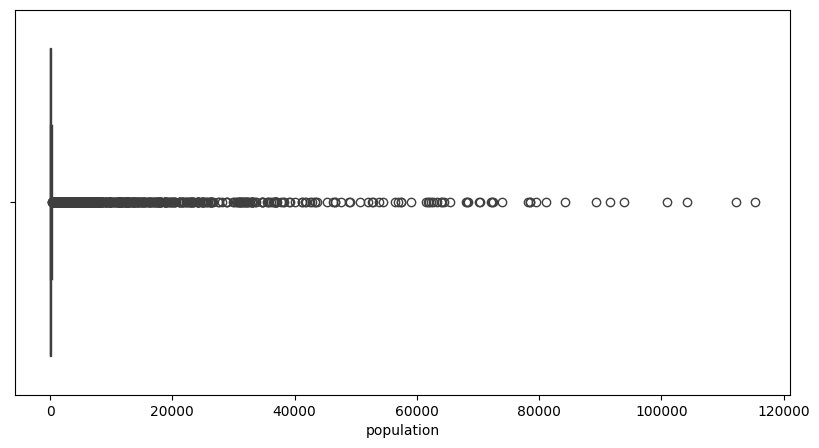

In [19]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df['population'])
plt.show()

The variable showed a highly right-skewed distribution, with a small number of very large population counts. These extreme values were retained because they represent genuine large refugee populations and are important for humanitarian resource planning. Removing them would reduce the model's ability to capture large-scale displacement events.

### 5.7 Final Validation of data

In [20]:
print(df.shape)
df.info()
df.head()

(8540, 13)
<class 'pandas.core.frame.DataFrame'>
Index: 8540 entries, 0 to 27661
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   origin_location_code  8540 non-null   object 
 1   origin_has_hrp        8540 non-null   int64  
 2   origin_in_gho         8540 non-null   int64  
 3   asylum_location_code  8540 non-null   object 
 4   asylum_has_hrp        8540 non-null   bool   
 5   asylum_in_gho         8540 non-null   bool   
 6   population_group      8540 non-null   object 
 7   gender                8540 non-null   object 
 8   age_range             8540 non-null   object 
 9   min_age               8540 non-null   float64
 10  max_age               6832 non-null   float64
 11  population            8540 non-null   int64  
 12  year                  8540 non-null   int32  
dtypes: bool(2), float64(2), int32(1), int64(3), object(5)
memory usage: 783.9+ KB


,origin_location_code,origin_has_hrp,origin_in_gho,asylum_location_code,asylum_has_hrp,asylum_in_gho,population_group,gender,age_range,min_age,max_age,population,year
0,AFG,1,1,KEN,False,True,ASY,f,0-4,0.0,4.0,0,2020
1,AFG,1,1,KEN,False,True,ASY,f,5-11,5.0,11.0,0,2020
2,AFG,1,1,KEN,False,True,ASY,f,12-17,12.0,17.0,0,2020
3,AFG,1,1,KEN,False,True,ASY,f,18-59,18.0,59.0,0,2020
4,AFG,1,1,KEN,False,True,ASY,f,60+,60.0,NaN,0,2020


Zero population values are observed across all age groups, with the largest number occurring among children aged 0–4 years. Since the zeros are spread throughout the age categories rather than concentrated in a single group, they are more likely to represent valid observations than systematic data errors. The zero values will be retained because there is no evidence that they are caused by age-specific reporting problems.

## 6. Exploratory Data Analysis


### 6.1 Univariate Analysis


All variables in the dataset except population are categorical and repeat throughout the dataset with equal frequency, so univariate counts add limited insight. The remainder of the EDA therefore focuses on bivariate and multivariate analysis, which reveal how population varies across categories.

#### 6.1.1 Gender Distribution by Records

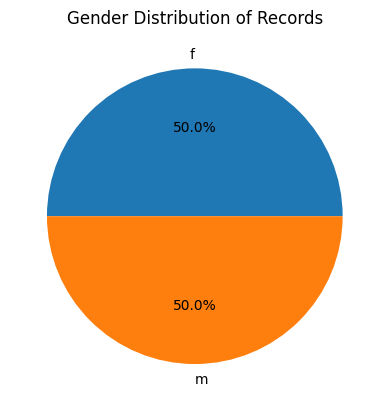

In [21]:
df['gender'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Gender Distribution of Records")
plt.ylabel("")
plt.show()

The pie chart shows 50% female (f) and 50% male (m) records indicating dataset contains an equal number of observations for each gender category

#### 6.1.2 Origin Location Distribution

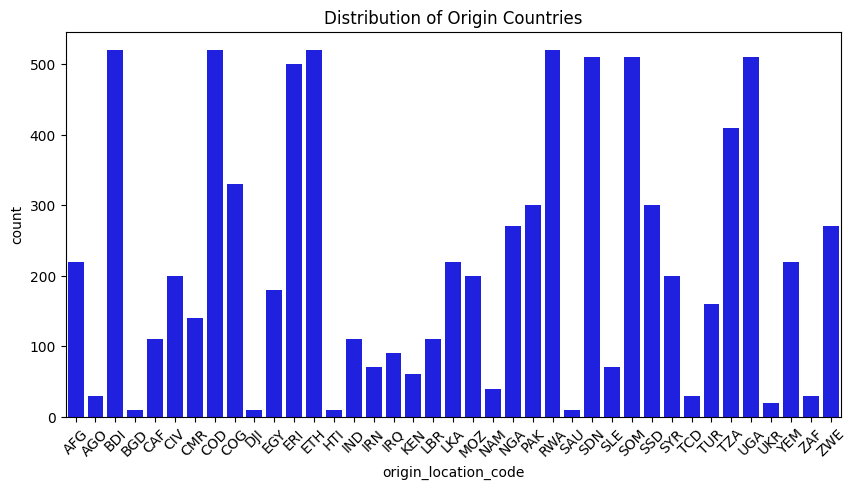

In [22]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="origin_location_code",
    order=sorted(df["origin_location_code"].unique()),
    color='blue'
)

plt.title("Distribution of Origin Countries")
plt.xticks(rotation=45)
plt.show()

The plot shows the representation of different refugee origin countries within the dataset. The number of records varies across countries due to differences in reporting frequency and duration of refugee presence. This provides an understanding of data coverage across origin countries before further population analysis.



### 6.2 Bivariate Analysis


#### 6.2.1 Top 10 Countries of Origin by Total Refugee Population


<function matplotlib.pyplot.show(close=None, block=None)>

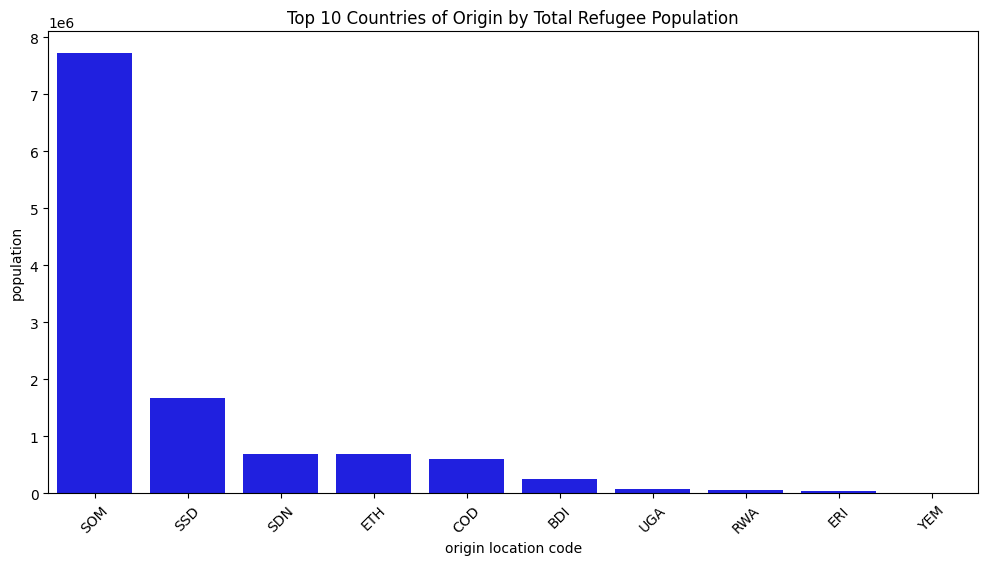

In [23]:
#Grouping origin location codes and finding the total population for each one of them.
country_population = (
    df.groupby('origin_location_code')['population']
        .sum()
        .reset_index()
)

top_10 = (
    country_population
    .sort_values(by = 'population', ascending = False)
    .head(10)
)

#Plotting the bar based on the grouped data above.
plt.figure(figsize=(12,6))

sns.barplot(data=top_10, x= 'origin_location_code', y = 'population', color='blue')

plt.title("Top 10 Countries of Origin by Total Refugee Population")
plt.xlabel("origin location code")
plt.ylabel("population")
plt.xticks(rotation=45)
plt.show




Based on the above bar chart, the maximum refugees that end up in Kenya are from Somalia,followed by South Sudan by a very big distance followed by Sudan,Ethiopia and Congo. This is to say that Kenyan refugees comes from the immediate neignbbouring countries rather than countries that involve crossing multiple borders to get to Kenya.

In [24]:
#Running the dataframe for visibility
df.head()

,origin_location_code,origin_has_hrp,origin_in_gho,asylum_location_code,asylum_has_hrp,asylum_in_gho,population_group,gender,age_range,min_age,max_age,population,year
0,AFG,1,1,KEN,False,True,ASY,f,0-4,0.0,4.0,0,2020
1,AFG,1,1,KEN,False,True,ASY,f,5-11,5.0,11.0,0,2020
2,AFG,1,1,KEN,False,True,ASY,f,12-17,12.0,17.0,0,2020
3,AFG,1,1,KEN,False,True,ASY,f,18-59,18.0,59.0,0,2020
4,AFG,1,1,KEN,False,True,ASY,f,60+,60.0,NaN,0,2020


#### 6.2.2 Population Group and Total Refugee Population Distribution

<function matplotlib.pyplot.show(close=None, block=None)>

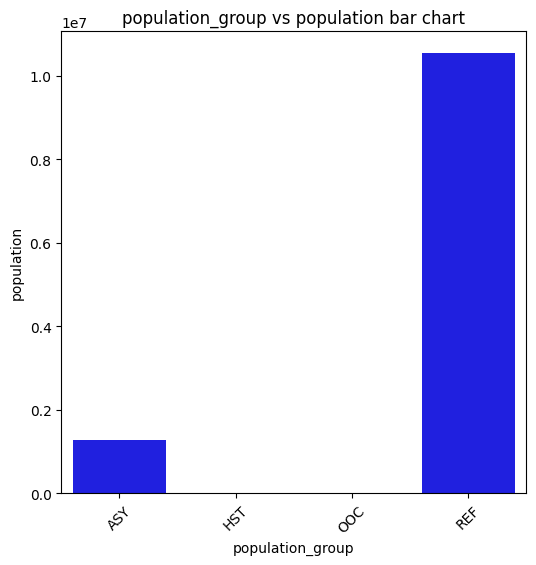

In [25]:
#The plot below is for population group which is either asylum or refugee etc against population

#creating a variable which groups the data by population group and computes the total population of each.
population_g_population = (
    df.groupby('population_group')['population']
        .sum()
        .reset_index()
)

#Plotting the bar graph
plt.figure(figsize=(6,6))

sns.barplot(data=population_g_population, x= 'population_group', y = 'population', color='blue')

plt.title("population_group vs population bar chart")
plt.xlabel("population_group")
plt.ylabel("population")
plt.xticks(rotation=45)
plt.show

The bar graph stresses on 2 categories which is Refugee and Asylum. With refugees being the people who receive their official status of being refugees while int heir origin country while asylum seekers receive their official status while already in the destination country.

However it is, the refugees are the majority 10-foled. This is a good indicator for humanitarian organizations in resource planning as most individuals are already identified while they are still in their country of origin. This gives lead time before they arrive in the destination country.

The other 2 categories are for Host Community and Others of Concern. These form a very negligible part of the data and aren't expected to have much impact on the final models.

#### 6.2.3 Total Refugee Population Distribution by Gender

C:\Users\user\AppData\Local\Temp\ipykernel_5052\3552948291.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Gender',)


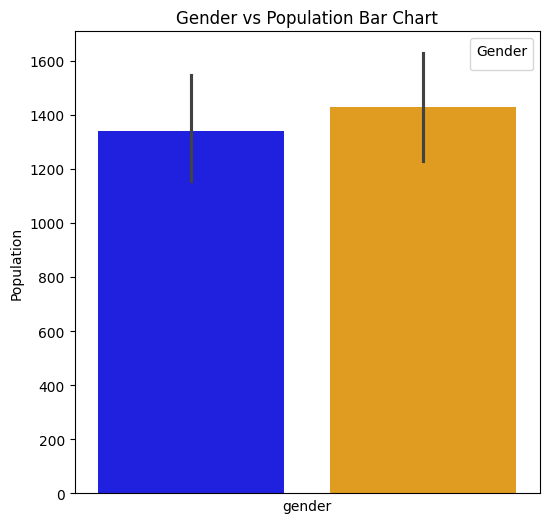

In [26]:
#The plot below is for gender against population
plt.figure(figsize=(6,6))

sns.barplot(
    data=df,
    x='gender',
    y='population',
    hue='gender',
    palette={'m': 'orange', 'f': 'blue'}
)

plt.title("Gender vs Population Bar Chart")
plt.xticks([])
plt.ylabel("Population")
plt.legend(title='Gender',)
plt.show()

The visualization highlights the relative contribution of each gender category to the overall refugee population. Differences between male and female population totals may indicate variations in demographic composition across the recorded refugee groups.


#### 6.2.4 Country of Origin and Gender Distribution (Top 10 Countries)

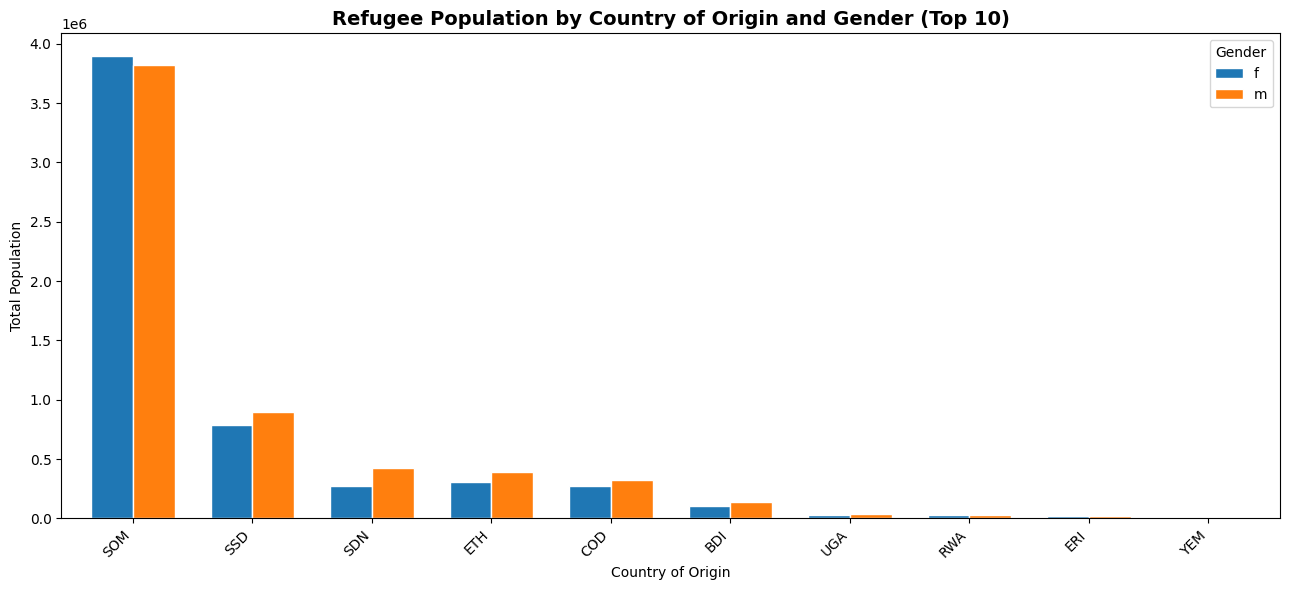

In [27]:
# Get top 10 countries by total population
top10_countries = (
    df.groupby('origin_location_code')['population']
      .sum()
      .nlargest(10)
      .index
)

country_gender = pd.pivot_table(
    df[df['origin_location_code'].isin(top10_countries)],
    values='population',
    index='origin_location_code',
    columns='gender',
    aggfunc='sum'
)


# Sort by total population descending
country_gender['total'] = country_gender.sum(axis=1)
country_gender = (
    country_gender.sort_values('total', ascending=False)
                  .drop('total', axis=1)
)

country_gender.plot(
    kind='bar',
    figsize=(13, 6),
    color=['tab:blue', 'tab:orange'],  # Female = blue, Male = orange
    edgecolor='white',
    width=0.7
)

plt.title(
    'Refugee Population by Country of Origin and Gender (Top 10)',
    fontsize=14,
    fontweight='bold'
)
plt.ylabel('Total Population')
plt.xlabel('Country of Origin')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()



The nearly equal proportion of men and women suggests that displacement from the main countries of origin affects both genders at similar rates. For humanitarian planners, this indicates that gender-responsive interventions should receive balanced funding and staffing.

#### 6.2.5 Refugee Population by Age Group

<function matplotlib.pyplot.show(close=None, block=None)>

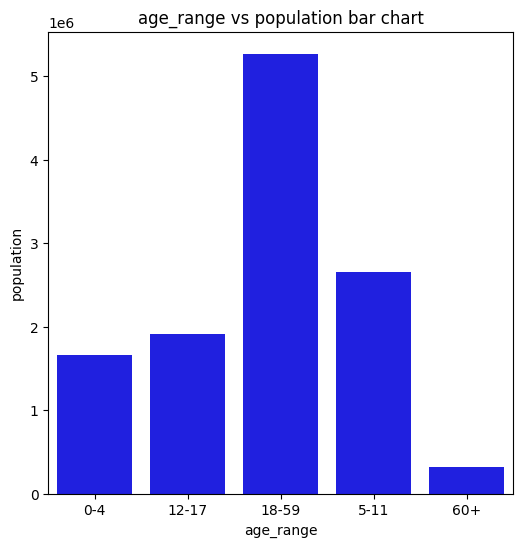

In [28]:
#Plotting a baer chart for age range against population

#Grouping age range and getting the total of population for each category
age_range_population = (
    df.groupby('age_range')['population']
        .sum()
        .reset_index()
)

#Plotting the figure

plt.figure(figsize=(6,6))

sns.barplot(data=age_range_population, x= 'age_range', y = 'population', color='blue')

plt.title("age_range vs population bar chart")
plt.xlabel("age_range")
plt.ylabel("population")
#plt.xticks(rotation=45)
plt.show

The 18–59 age group forms the largest share of the population due to its broad age range. Children (0–17) also make up a significant proportion, highlighting the need for education, child protection, and nutrition services. Although the 60+ group is the smallest, it has the greatest healthcare needs. The UNHCR Age, Gender and Diversity (AGD) framework emphasizes planning based on age- and gender-disaggregated data to meet these diverse needs.


#### 6.2.6 Distribution of Refugee Population over the years

<function matplotlib.pyplot.show(close=None, block=None)>

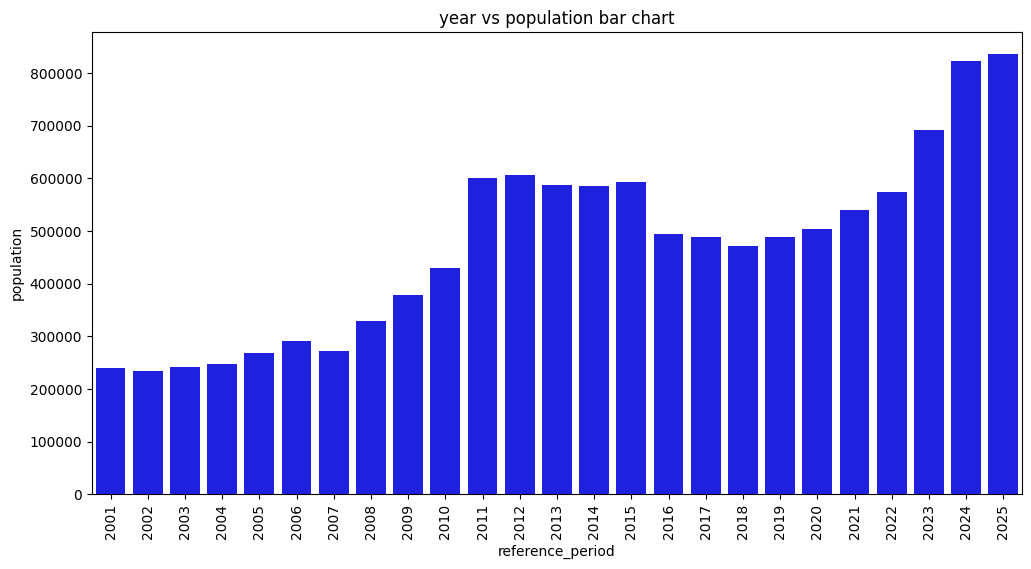

In [29]:
#Plotting a bar chart for the reference years against population

#Grouping the data based on years and then finding the sum of each.
period_population = (
    df.groupby('year')['population']
        .sum()
        .reset_index()
)

#Plotting thebar

plt.figure(figsize=(12,6))

sns.barplot(data=period_population, x= 'year', y = 'population', color='blue')

plt.title("year vs population bar chart")
plt.xlabel("reference_period")
plt.ylabel("population")
plt.xticks(rotation=90)
plt.show



The trend shows three phases: rapid growth (2001–2011), a period of stability and slight decline (2012–2019), and renewed growth from 2020 onward due to escalating regional conflicts. This non-linear pattern demonstrates that simple trend-based forecasting is inadequate, highlighting the need for machine learning models that can better capture complex population dynamics.


### 6.3 Multivariate Analysis


Two variables at a time can only tell you so much. Multivariate analysis looks at three or more simultaneously, surfacing the layered demographic patterns that stay hidden in simpler views.

For humanitarian organizations, understanding how age, gender, country of origin, and population interact is essential for effective resource planning and forecasting.

The four analyses below move from demographic composition to country-gender dynamics to origin dominance to temporal trends, building
a complete picture of Kenya's refugee population structure.


#### 6.3.1 Age Range, Gender and Population

##### Business Question 
How is the refugee population distributed across different age groups and genders?

Understanding the demographic composition of refugee populations can help humanitarian agencies allocate healthcare, education, protection services, and livelihood programs more effectively.

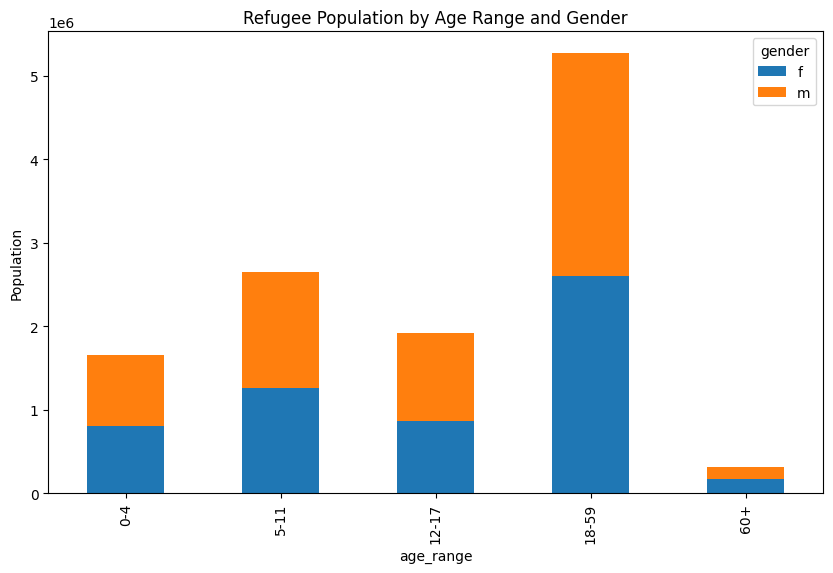

In [30]:
age_gender = pd.pivot_table(
    df,
    values='population',
    index='age_range',
    columns='gender',
    aggfunc='sum'
)
age_order = ['0-4', '5-11', '12-17', '18-59', '60+']
age_gender = age_gender.reindex(age_order)
age_gender.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6)
)

plt.title('Refugee Population by Age Range and Gender')
plt.ylabel('Population')
plt.show()



The 18–59 working-age group is the largest demographic for both males and females, reflecting that displacement is primarily experienced by adults escaping conflict or persecution. Children aged 0–17 also make up a considerable share of the population, while those aged 60 and above represent the smallest group. Gender distribution remains relatively balanced across all age categories, with neither sex having significant dominance.

##### Business Insight

The demographic profile has important planning implications. The large 18–59 population drives demand for livelihood, skills training, and adult mental health services. The sizeable 0–17 population calls for sustained investment in education, nutrition, and child protection. Although the 60+ group is small, it has greater healthcare needs, consistent with the UNHCR Age, Gender and Diversity (AGD) framework. The balanced gender distribution also calls for equitable provision of gender-responsive services, including reproductive healthcare, GBV prevention, and psychosocial support.



#### 6.3.2 Country of Origin, Gender and Population

##### Business Question

How does gender composition vary across top refugee-producing countries?

Spotting gender patterns by country of origin helps agencies identify vulnerable populations and design interventions that actually fit.

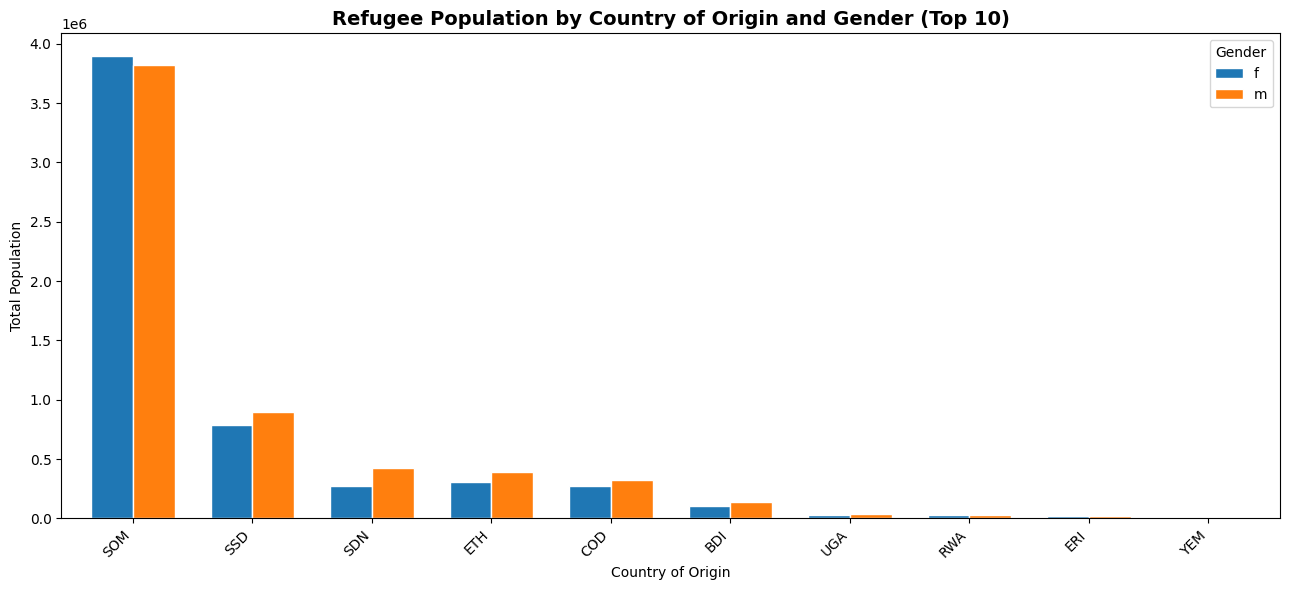

In [31]:
# Get top 10 countries by total population
top10_countries = (
    df.groupby('origin_location_code')['population']
      .sum()
      .nlargest(10)
      .index
)

country_gender = pd.pivot_table(
    df[df['origin_location_code'].isin(top10_countries)],
    values='population',
    index='origin_location_code',
    columns='gender',
    aggfunc='sum'
)


# Sort by total population descending
country_gender['total'] = country_gender.sum(axis=1)
country_gender = (
    country_gender.sort_values('total', ascending=False)
                  .drop('total', axis=1)
)

country_gender.plot(
    kind='bar',
    figsize=(13, 6),
    color=['tab:blue', 'tab:orange'],  # Female = blue, Male = orange
    edgecolor='white',
    width=0.7
)

plt.title(
    'Refugee Population by Country of Origin and Gender (Top 10)',
    fontsize=14,
    fontweight='bold'
)
plt.ylabel('Total Population')
plt.xlabel('Country of Origin')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()



Somalia (SOM) is the largest source country by a wide margin, followed by South Sudan (SSD), DRC, Ethiopia (ETH), Sudan (SDN), and Burundi (BDI). Gender distribution is generally balanced, with Somalia showing a slight female majority, while Ethiopia and Eritrea display more balanced or slightly male-leaning patterns, reflecting differences in displacement dynamics.


##### Business Insight

The high concentration of refugees from Somalia and South Sudan means that forecasting these two populations is critical to the effectiveness of the planning system. Inaccuracies for these countries would have a greater impact on resource allocation than errors involving smaller origin groups. Gender patterns also influence programme needs: female-majority populations may require increased support for female-headed households, including protection, shelter, and livelihood assistance, while balanced or male-skewed populations may reflect different migration patterns requiring tailored psychosocial and economic support. Countries experiencing recent population growth should be closely monitored for changing gender trends that may affect future planning.


#### 6.3.3. Top 10 Countries of Origin vs Relative Population Share (Treemap)

##### Business Question

Which origin countries contribute the largest total refugee populations
to Kenya, and how stark is the concentration among the top contributors
relative to the rest?

In [32]:
# Install the squarify library for creating treemaps
%pip install squarify

Note: you may need to restart the kernel to use updated packages.


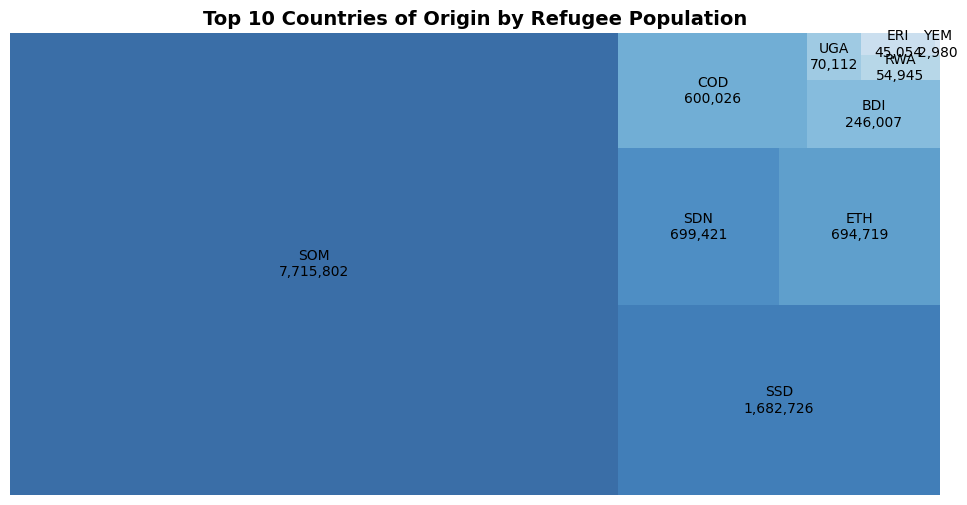

In [33]:
import squarify

# Top 10 countries by population
country_pop = (
    df.groupby('origin_location_code')['population']
      .sum()
      .nlargest(10)
)

# Labels
labels = [f"{c}\n{v:,.0f}" for c, v in country_pop.items()]

plt.figure(figsize=(12, 6))

squarify.plot(
    sizes=country_pop.values,
    label=labels,
    color=plt.cm.Blues(range(230, 30, -20)),
    alpha=0.8
)

plt.title('Top 10 Countries of Origin by Refugee Population',
          fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()



The treemap makes the concentration impossible to miss: Somalia dominates by far, South Sudan a clear second, with DRC, Ethiopia, Sudan, and Burundi contributing smaller but still meaningful shares. The remaining top 10 countries account for only a limited share, and the exclusion of around 29 other origin countries further demonstrates the dominance of the largest sources.


##### Business Insight

This concentration has direct implications for how the forecasting models should be built. High-volume countries such as Somalia, South Sudan, DRC, Ethiopia, and Sudan should have separate models to improve accuracy, while smaller groups are better suited to simpler pooled approaches to reduce overfitting. Since Somalia has the greatest impact on overall estimates, accurate forecasting is essential. Emerging instability in mid-sized sources like Ethiopia and DRC also requires ongoing monitoring, as their displacement trends may change significantly over the next few years.



#### 6.3.4 Population Group by Age group

How are the four population groups (REF, ASY, HST, OOC) distributed across age cohorts, and what does this imply for group-specific humanitarian programming?

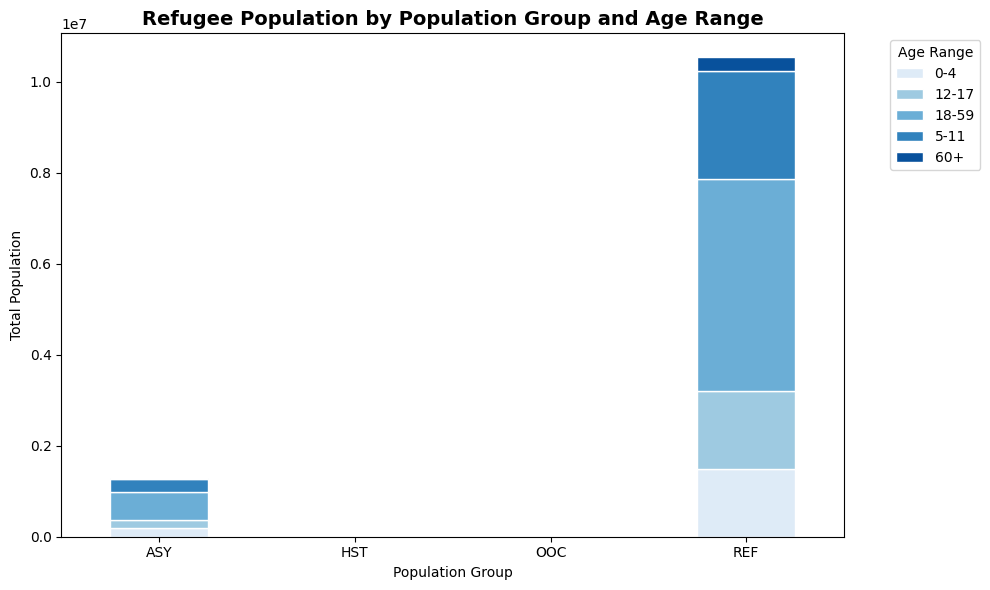

In [34]:
pop_group_age = pd.pivot_table(
    df,
    values='population',
    index='population_group',
    columns='age_range',
    aggfunc='sum'
)

pop_group_age.plot(
    kind='bar',
    stacked=True,
    figsize=(10, 6),
    color=['#DEEBF7', '#9ECAE1', '#6BAED6', '#3182BD', '#08519C'],
    edgecolor='white'
)

plt.title('Refugee Population by Population Group and Age Range',
          fontsize=14, fontweight='bold')
plt.ylabel('Total Population')
plt.xlabel('Population Group')
plt.xticks(rotation=0)
plt.legend(title='Age Range', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

The chart shows that different population groups contain varying proportions of individuals across age categories. Younger and adult age groups contribute substantially to the overall population, while the distribution of age categories differs between population groups.

#### 6.3.5 Year of Assylum, Country of Origin and Population

##### Business Question 

How have refugee population trends evolved over time for the five largest
origin countries?

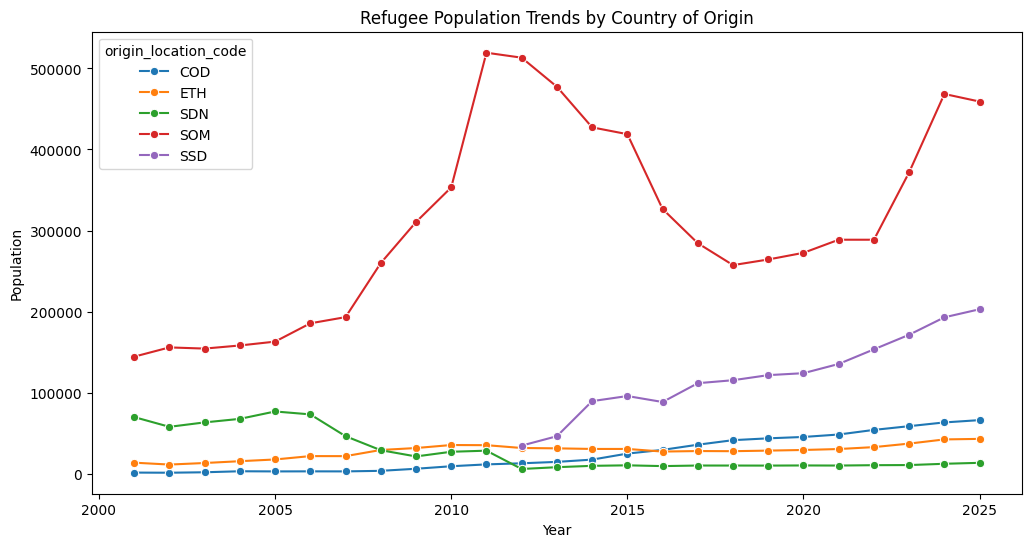

In [35]:

top_countries = (
    df.groupby('origin_location_code')['population']
      .sum()
      .nlargest(5)
      .index
)

year_country = (
    df[df['origin_location_code'].isin(top_countries)]
      .groupby(['year','origin_location_code'])['population']
      .sum()
      .reset_index()
)

plt.figure(figsize=(12,6))

sns.lineplot(
    data=year_country,
    x='year',
    y='population',
    hue='origin_location_code',
    marker='o'
)

plt.title('Refugee Population Trends by Country of Origin')
plt.xlabel('Year')
plt.ylabel('Population')

plt.show()



Somalia (SOM) remains the largest source population from 2001–2025, with a major surge around 2011, a slight decline during the mid-2010s, and renewed growth after 2020. South Sudan (SSD) experienced a sharp rise from 2013 following the civil war, becoming the second-largest origin group. Ethiopia (ETH) and DRC (COD) show persistent but smaller populations, with Ethiopia increasing after 2020 due to the Tigray conflict, while Sudan (SDN) shows a steady recent rise.


##### Business Insight

The trends highlight three key implications for the forecasting system. First, refugee movements are driven by major events rather than steady patterns, requiring ML models to capture sudden changes and incorporate external conflict indicators. Second, prolonged displacement is common, meaning models must account for stable long-term populations alongside crisis-related increases. Third, simultaneous growth across multiple countries after 2020 suggests regional instability, making multi-country surge scenarios essential for effective planning.


### 6.4 Correlation Heatmap of Numerical Features

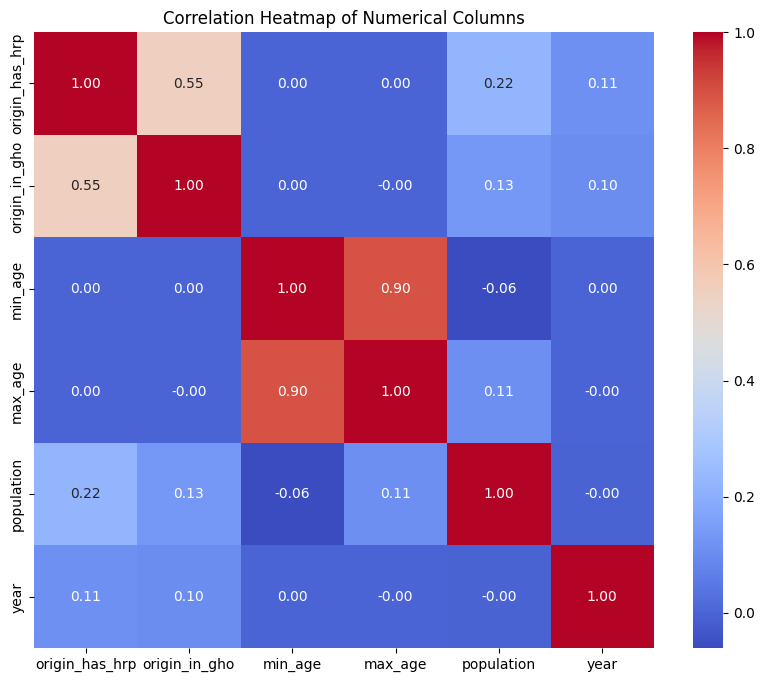

In [36]:
#Correlation heatmap for numerical columns
numerical_cols = df.select_dtypes(include=['number']).columns
correlation_matrix = df[numerical_cols].corr()
df[numerical_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Columns')
plt.show()

The correlation heatmap illustrates the relationships between numerical variables included in the dataset. Pearson correlation coefficients were calculated to identify the strength and direction of linear relationships between numerical features and the target variable, population.

The heatmap highlights the degree of association between variables such as year, humanitarian indicators, and population values. Features with stronger positive correlations indicate that increases in one variable are associated with increases in another, while negative correlations indicate an inverse relationship.

The correlation heatmap was used as an exploratory tool to support feature understanding rather than as the sole method for feature selection.

### 6.5  Exploratory Data Analysis Summary

The exploratory data analysis provided valuable insights into refugee population dynamics in Kenya.

Key findings include:

- Refugee populations are unevenly distributed, a handful demographic groups and countries contributing the largest populations.
- The working-age population (18–59 years) forms the largest age segment among refugees hosted in Kenya.
- Both male and female refugees contribute significantly to the overall population.
- A small number of countries drive the bulk of refugee inflows, even though dozens of countries are represented.
- Population trends vary over time, highlighting the dynamic nature of displacement and the importance of predictive analytics.
- Demographic patterns differ across age groups, genders, and countries of origin, suggesting varying humanitarian needs.
- The correlation analysis of numerical variables provides insight into linear relationships, it does not capture complex interactions between categorical and numerical variables.

These findings provide a strong foundation for feature engineering and predictive modeling. The identified demographic and temporal patterns will support the development of machine learning models capable of forecasting refugee population changes and improving humanitarian resource planning in Kenya.


## 7. Data Preprocessing

### 7.1 Feature Selection and Chronological Data Splitting
The input variables for the forecasting model were selected based on their relevance to refugee population prediction. The dataset contains both categorical and numerical features, which were separated to allow appropriate preprocessing within the machine learning pipeline.

The categorical features include origin location, population group, gender, and age range, representing demographic and geographic characteristics of refugee populations. The numerical features include humanitarian indicators origin_has_hrp and origin_in_gho and the extracted temporal feature year. The target variable was defined as population, representing the refugee and asylum-seeking population size to be predicted.

A chronological data split was applied rather than a random split to better represent a real-world forecasting scenario. Records from years up to and including 2022 were used for training, while records after 2022 were reserved for testing. This approach ensures that the model learns from historical observations and is evaluated on future periods, reducing the risk of information leakage and providing a more realistic assessment of forecasting performance.

In [37]:
# Define categorical features used as model inputs
categorical_cols = ['origin_location_code', 'population_group', 'gender', 'age_range']

# Define numerical features used as model inputs
base_num_cols = ['origin_has_hrp', 'origin_in_gho', 'year']

# Create feature matrix containing categorical and numerical variables
X = df[categorical_cols + base_num_cols].copy()

# Define target variable to be predicted
y = df['population'].copy()

# Create chronological training and testing split
# Historical data up to 2022 is used for training, later years for evaluation
train_mask = df['year'] <= 2022

# Split features into training and testing sets
X_train, X_test = X[train_mask], X[~train_mask]

# Split target values into training and testing sets
y_train, y_test = y[train_mask], y[~train_mask]

# Display the size of training and testing datasets
print(X_train.shape, X_test.shape)

(7060, 7) (1480, 7)


## 8. Model Development and Evaluation

### 8.1 Importing Libraries for Model Training and Evaluation

In [38]:
#libraries for model building
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score,accuracy_score,classification_report,confusion_matrix,f1_score)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor,plot_tree
from sklearn.preprocessing import LabelEncoder, StandardScaler  


#import necessary libraries for deep learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader




### 8.2 Model Pipeline Construction and Evaluation Framework

To ensure consistent preprocessing and evaluation across different machine learning models, a reusable pipeline was developed. The pipeline combines feature preprocessing with model training, allowing categorical variables to be transformed automatically before being passed to the predictive algorithm.

Categorical features were processed using one-hot encoding, where each category was converted into a numerical representation. The handle_unknown='ignore' parameter was applied to allow the model to process previously unseen categories during testing or future predictions without generating errors. Numerical variables were retained using the passthrough option, allowing them to be used directly by the model.

An evaluation function was created to automate the training, prediction, and performance assessment process. After fitting the pipeline on the training data, predictions were generated on the test dataset and evaluated using three regression metrics: Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the coefficient of determination (R²). These metrics provide complementary measures of prediction accuracy, error magnitude, and the model's ability to explain variation in refugee population values.

In [39]:
# Creation of  a pipeline 
def build_pipeline(model, categorical_cols):
    preprocess = ColumnTransformer(
        [('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)],
        remainder='passthrough'
    )
    return Pipeline([('prep', preprocess), ('model', model)])

# Evaluation function
def evaluate(pipe, X_tr, y_tr, X_te, y_te, name):
    pipe.fit(X_tr, y_tr)
    pred = pipe.predict(X_te)
    mae = mean_absolute_error(y_te, pred)
    rmse = np.sqrt(mean_squared_error(y_te, pred))
    r2 = r2_score(y_te, pred)
    print(f"{name:35s} MAE: {mae:9.2f}   RMSE: {rmse:9.2f}   R2: {r2:7.3f}")
    return mae, rmse, r2, pred

#### 8.2.1 Linear Regression

A Linear Regression model was implemented as a baseline approach to evaluate the forecasting performance of a traditional statistical learning method. Linear Regression assumes a linear relationship between the input features and the target variable, making it useful as a reference point for comparing more complex models.

The model was integrated into the preprocessing pipeline and evaluated using the test dataset, and performance was measured using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the coefficient of determination (R²).

Establishing a baseline model provides a comparison point for assessing whether advanced approaches, such as tree-based models and deep learning, provide improvements in capturing complex relationships within refugee population data.

In [40]:

#Linear Regression Model
lr_pipe = build_pipeline(
    LinearRegression(),
    categorical_cols
)

lr_mae, lr_rmse, lr_r2, lr_pred = evaluate(
    lr_pipe,
    X_train,
    y_train,
    X_test,
    y_test,
    "Linear Regression"
)

Linear Regression                   MAE:   2174.56   RMSE:   5005.00   R2:   0.429


In [41]:
# Make predictions using Linear Regression model
linear_predictions = lr_pred

# Display actual vs predicted values
prediction_results = pd.DataFrame({
    "Actual Population": y_test.values,
    "Predicted Population": linear_predictions
})

prediction_results.head(20)

,Actual Population,Predicted Population
0,5,-1818.097297
1,7,-1274.596044
2,0,-1703.097741
3,35,198.376130
4,0,-2604.081902
5,0,-1728.974634
6,8,-1185.473381
7,14,-1613.975078
8,31,287.498793
9,0,-2514.959239


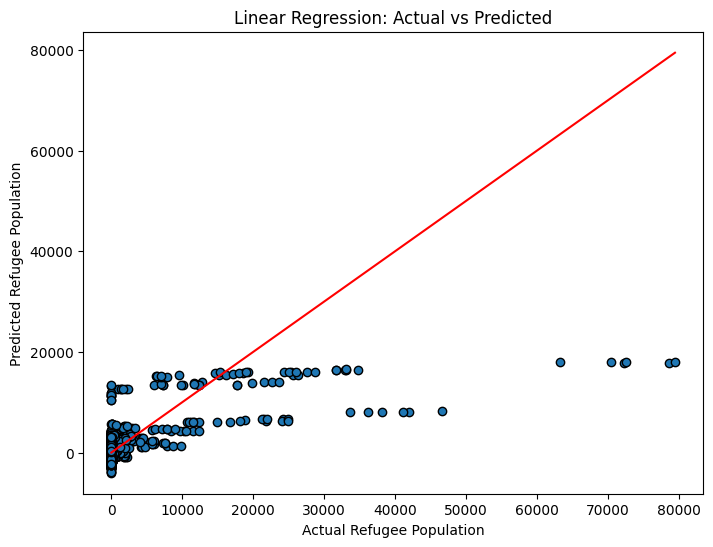

In [42]:
# Plotting Actual vs Predicted values for Linear Regression
plt.figure(figsize=(8,6))

plt.scatter(y_test, lr_pred,edgecolors='k')

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red")


plt.xlabel("Actual Refugee Population")
plt.ylabel("Predicted Refugee Population")
plt.title("Linear Regression: Actual vs Predicted")

plt.show()



Linear Regression achieved an MAE of **2,174.56**, an RMSE of **5,005.01** and an R² of **0.429**. The RMSE being much higher than the MAE indicates that some observations had very large errors. The model also generated negative population predictions which is impossible in the real world and confirms what the correlation heatmap already hinted: a straight line simply can't capture the complex, non-negative nature of refugee population data.


#### 8.2.2 Decision Tree Regression

Where Linear Regression fell short, the Decision Tree Regressor gets a chance to prove nonlinear relationships matter, learning to predict refugee population from country of origin, age group, sex, and the rest of the demographic picture.

In [43]:
# Decision Tree Model
dt_pipe = build_pipeline(
    DecisionTreeRegressor(
        max_depth=12,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42
    ),
    categorical_cols
)

# Evaluate the pipeline and get predictions
dt_mae, dt_rmse, dt_r2, dt_pred = evaluate(
    dt_pipe,
    X_train,
    y_train,
    X_test,
    y_test,
    "Decision Tree"
)

Decision Tree                       MAE:    484.93   RMSE:   2282.01   R2:   0.881


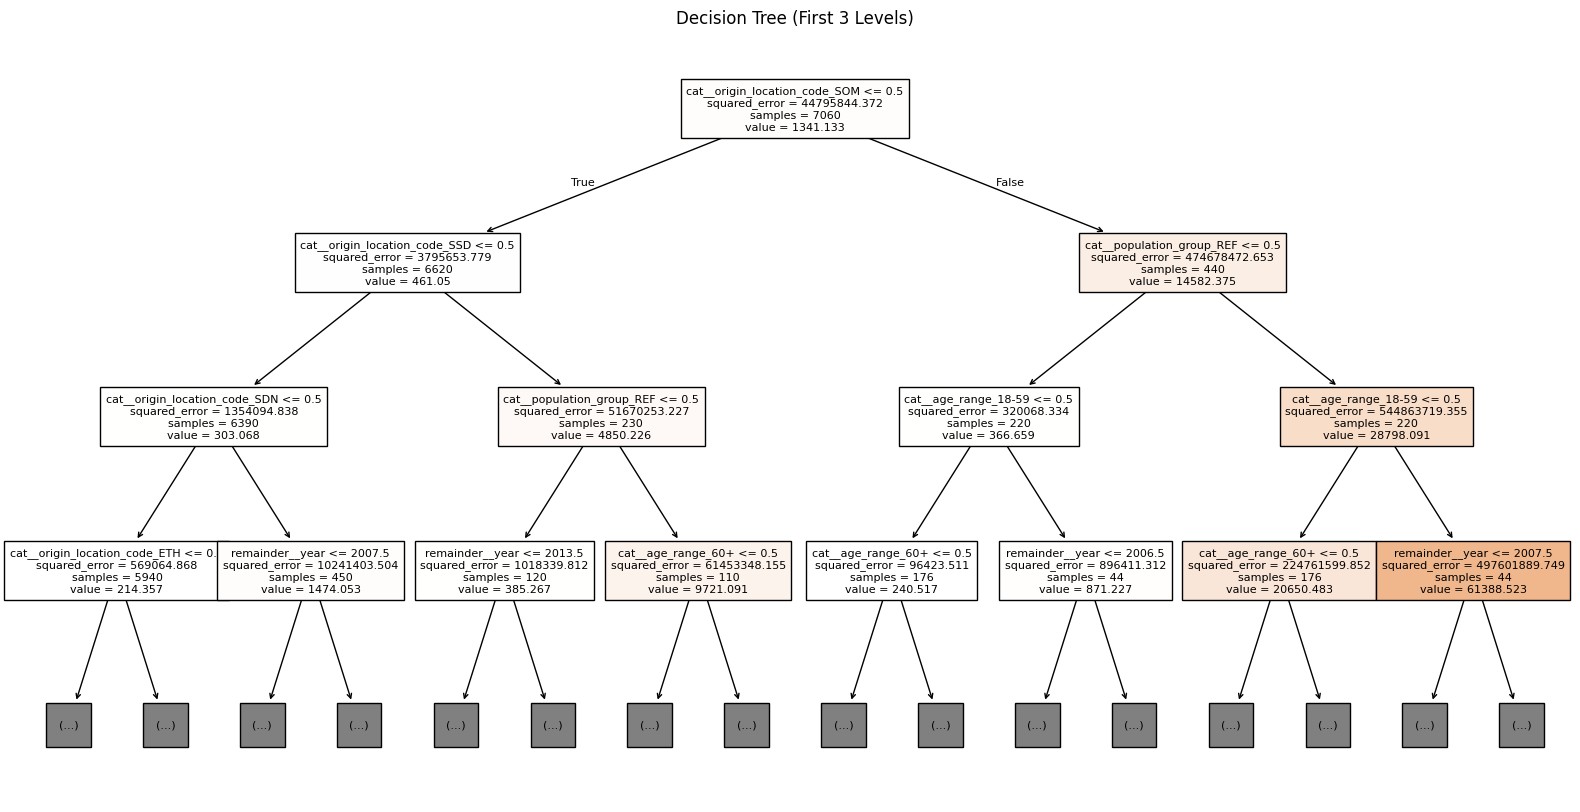

In [44]:
# Visualize tree (first few levels)
plt.figure(figsize=(20,10))
plot_tree(dt_pipe.named_steps['model'],
                    feature_names=dt_pipe.named_steps['prep'].get_feature_names_out(),
                    max_depth=3, filled=True, fontsize=8)
plt.title("Decision Tree (First 3 Levels)")
plt.show()

The upgrade is immediate. The Decision Tree Regressor captured nonlinear relationships between refugee population and country of origin, population group, gender, age group, and year with tree depth, node splitting, and leaf size all constrained to keep complexity in check. The results: an R² of **0.881**, MAE of **484.93**, and RMSE of **2,282.01** a dramatic leap over Linear Regression. The tree visualization makes the mechanism visible too, showing exactly how the model splits observations into smaller and smaller groups on its way to a prediction.

#### 8.2.3 Random Forest

Random Forest takes the Decision Tree idea and multiplies it: Multiple trees each trained on a random slice of the data and a random subset of features, with predictions averaged across the whole ensemble. That averaging is exactly what tames a single tree's tendency to overfit.



In [45]:
# Random Forest Model
rf_pipe = build_pipeline(
    RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),
    categorical_cols
)

rf_mae, rf_rmse, rf_r2, rf_pred = evaluate(
    rf_pipe,
    X_train,
    y_train,
    X_test,
    y_test,
    "Random Forest"
)

Random Forest                       MAE:    466.63   RMSE:   2285.70   R2:   0.881


The result is the strongest performer yet, an MAE of **466.63**, RMSE of **2,285.70**, and R² of **0.881**, edging out the single Decision Tree on MAE while matching it closely on RMSE and R². By pooling the wisdom of many trees instead of relying on one, Random Forest delivers the most consistent, reliable predictions among the tree-based models so far.

#### 8.2.4 XGBoost (eXtreme Gradient Boosting)

XGBoost builds an army of sequential Decision Trees, each one correcting the mistakes of the last, to learn nonlinear relationships between demographic, geographic, and temporal variables and refugee population counts.

##### 8.2.4.1 Package for XGBoost

In [46]:
#Installing XGBoost
!pip install xgboost

In [47]:
#library for XGBoost
from xgboost import XGBRegressor

In [48]:
# XGBoost Model
xgb_pipeline = build_pipeline(
    XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        random_state=42,
        objective="reg:squarederror"
    ),
    categorical_cols
)

xgb_mae, xgb_rmse, xgb_r2, xgb_pred = evaluate(
    xgb_pipeline,
    X_train,
    y_train,
    X_test,
    y_test,
    "XGBoost"
)

XGBoost                             MAE:    548.37   RMSE:   2373.54   R2:   0.872


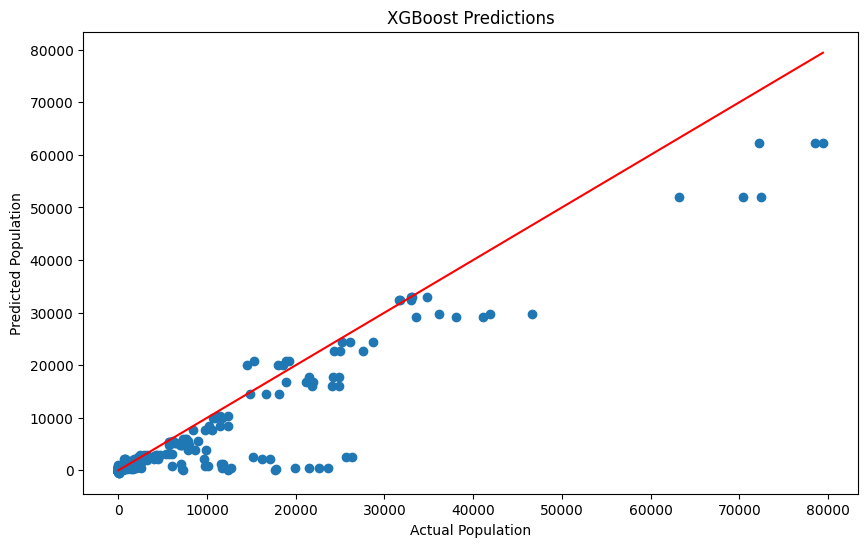

In [49]:
# Plotting Actual vs Predicted values for XGBoost
plt.figure(figsize=(10,6))

plt.scatter(y_test, xgb_pred )

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.xlabel("Actual Population")
plt.ylabel("Predicted Population")
plt.title("XGBoost Predictions")

plt.show()

The model achieved an MAE of 534.29, an RMSE of 2,333.38 and an R² of 0.876. This indicates strong predictive performance, although it performed slightly below the original Random Forest and Decision Tree models on the test data.

### 8.3  FT-Transformer Model

Linear Regression, Decision Trees, Random Forest, and XGBoost all treat refugee population forecasting as a conventional tabular regression problem.

The **FT-Transformer (Feature Tokenizer Transformer)** takes a different approach entirely. Instead of one-hot encoding or hand-built feature crosses, every categorical and numerical feature is converted into its own dense embedding — a "token." A stack of Multi-Head Self-Attention layers then lets the model discover interactions between *all* of those tokens on its own, with no manual feature engineering required.




The implemented FT-Transformer architecture consists of four main components that enable the model to process mixed categorical and numerical humanitarian indicators.

1. **Numerical Tokenizer**  
   Numerical variables, such as year and humanitarian indicators (HRP/GHO status), are projected into the same embedding space as categorical features using a learnable numerical tokenizer. This allows continuous variables to be represented as feature tokens and processed together with categorical information within the Transformer architecture.

2. **Categorical Tokenizer**  
   Each categorical feature, including origin country, population group, gender, and age range, is represented using a dedicated embedding layer. These embeddings transform discrete categories into dense numerical vectors, allowing the model to learn meaningful relationships between different categorical values.
   
3. **Transformer Encoder**  
   The tokenized features are passed through multiple Transformer encoder layers based on Multi-Head Self-Attention. This mechanism enables the model to learn interactions between different feature tokens by identifying relationships among demographic, temporal, geographic, and humanitarian variables without requiring manually created feature interactions.

4. **Prediction Head**  
   The output from the Transformer encoder is flattened and passed through a feed-forward neural network. The prediction head transforms the learned feature representations into a single continuous output representing the estimated refugee and asylum-seeking population.

#### 8.3.1 Computational Device Configuration

Before training the FT-Transformer model, the available computing device was identified to optimise model execution. The implementation automatically checks whether a CUDA-enabled GPU is available and uses GPU acceleration when possible. If no compatible GPU is detected, the model runs using the CPU.

Using GPU acceleration can significantly reduce training time for deep learning models by enabling parallel processing of tensor operations.

In [50]:
# Configure computing device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on: {device}")

Running on: cpu


#### 8.3.2 Creating a Deep Learning Dataset Copy and Data Preprocessing for FT-Transformer

A separate copy of the cleaned dataset was created for deep learning model preparation. This ensured that transformations required for the FT-Transformer, such as encoding and scaling, did not modify the original dataset used for exploratory analysis and comparison.

Before training the FT-Transformer model, the numerical features were checked to ensure that they contained valid values suitable for neural network processing.

In [51]:
#Creating a working copy of the dataset for deep learning model
df_dl = df.copy()

print("Dataset Shape:", df_dl.shape)

df_dl.head()

Dataset Shape: (8540, 13)


,origin_location_code,origin_has_hrp,origin_in_gho,asylum_location_code,asylum_has_hrp,asylum_in_gho,population_group,gender,age_range,min_age,max_age,population,year
0,AFG,1,1,KEN,False,True,ASY,f,0-4,0.0,4.0,0,2020
1,AFG,1,1,KEN,False,True,ASY,f,5-11,5.0,11.0,0,2020
2,AFG,1,1,KEN,False,True,ASY,f,12-17,12.0,17.0,0,2020
3,AFG,1,1,KEN,False,True,ASY,f,18-59,18.0,59.0,0,2020
4,AFG,1,1,KEN,False,True,ASY,f,60+,60.0,NaN,0,2020


In [52]:
#Reconfirming no missing values in the numerical columns and replacing any infinite values with NaN, then filling NaN with 0
df_dl[numerical_cols] = (
    df_dl[numerical_cols]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

##### 8.3.3 Encoding Categorical Features

The FT-Transformer requires categorical variables to be represented as numerical indices before they can be passed into embedding layers. Label encoding was applied to categorical features, including origin location, population group, gender, and age range.

Each unique category was assigned an integer value, allowing the model to create learnable embedding representations for each categorical feature. The number of unique categories for each feature was also stored to define the embedding layer dimensions within the FT-Transformer architecture.

In [53]:
#Encoding categorical columns using LabelEncoder
label_encoders = {}

cat_num_classes = []

for column in categorical_cols:

    encoder = LabelEncoder()

    df_dl[column] = encoder.fit_transform(
        df_dl[column]
    )

    label_encoders[column] = encoder

    cat_num_classes.append(
        df_dl[column].nunique()
    )

#### 8.3.4 Scaling Numerical Features

Numerical features were standardised using StandardScaler to improve model training stability. Standardisation transforms numerical variables so that they have a mean of approximately zero and a standard deviation of one.

Scaling prevents numerical features with larger ranges from dominating the learning process and allows the neural network to optimise more effectively during training.

In [54]:
#Standardizing numerical features using StandardScaler
scaler_x = StandardScaler()

df_dl[numerical_cols] = scaler_x.fit_transform(
    df_dl[numerical_cols]
)

#### 8.3.5 Dataset Splitting for FT-Transformer

An 80/20 split was applied, where 80% of the observations were used for model training and the remaining 20% were reserved for testing.

The categorical and numerical features were separated because the FT-Transformer processes these feature types differently. Categorical variables are passed through embedding layers, while numerical variables are provided as continuous inputs after standardisation.


In [55]:
# Define an 80% training and 20% testing split
split = int(len(df_dl)*0.8)   

# Extract categorical and numerical feature arrays
X_cat = df_dl[categorical_cols].values
X_num = df_dl[numerical_cols].values

# Define the target variable
target_col = "population"
y=df_dl[target_col].values

# Split categorical features into training and testing sets
X_train_cat = X_cat[:split]
X_test_cat = X_cat[split:]

# Split numerical features into training and testing sets
X_train_num = X_num[:split]
X_test_num = X_num[split:]


# Split target values into training and testing sets
y_train = y[:split]
y_test = y[split:]


#### 8.3.6 PyTorch Dataset and DataLoader Preparation

Before training the FT-Transformer model, the prepared feature arrays were converted into PyTorch-compatible datasets. A custom Dataset class was created to organise categorical features, numerical features, and target values into tensors that can be efficiently processed by the neural network.

Categorical variables were converted into integer tensors (**torch.long**) because they are used as inputs to embedding layers within the FT-Transformer. Numerical variables were converted into floating-point tensors (**torch.float32**) because they represent continuous values processed by the numerical tokenizer.

The target variable, population size, was also converted into a floating-point tensor and reshaped to match the regression output format of the model.

PyTorch DataLoader objects were then created to manage batch processing during training and evaluation. The training loader uses shuffled batches to improve model learning, while the testing loader maintains the original order to ensure consistent evaluation.

In [56]:
# PyTorch Tabular Dataset class
class TabularDataset(Dataset):
    def __init__(self, X_cat, X_num, y):
        self.X_cat = torch.tensor(X_cat, dtype=torch.long)
        self.X_num = torch.tensor(X_num, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)
        
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X_cat[idx], self.X_num[idx], self.y[idx]

# Create DataLoaders
train_dataset = TabularDataset(X_train_cat, X_train_num, y_train)
test_dataset = TabularDataset(X_test_cat, X_test_num, y_test)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)



The dataset was wrapped in a custom **TabularDataset** so each batch yields categorical indices, numerical values, and the target population together. Training batches are shuffled to help learning; test batches aren't, since order has no bearing on evaluation.

#### 8.3.6 Architecture of the Deep Learning Model

In [57]:
#  FT-Transformer model modules
#Numerical Tokenizer for numerical features
class NumericalTokenizer(nn.Module):
    """
    Converts numerical features into learnable token embeddings.
    Each numerical feature is projected into an embedding space.
    """
    
    def __init__(self, num_features, embed_dim):
        super().__init__()
        self.weights = nn.Parameter(torch.Tensor(num_features, embed_dim))
        self.biases = nn.Parameter(torch.Tensor(num_features, embed_dim))
        nn.init.xavier_uniform_(self.weights)
        nn.init.zeros_(self.biases)

    def forward(self, x):
        # x shape: [batch_size, num_features]
        # output shape: [batch_size, num_features, embed_dim]
        return x.unsqueeze(-1) * self.weights.unsqueeze(0) + self.biases.unsqueeze(0)

#Categorical Tokenizer for categorical features
class FTTransformer(nn.Module):
    def __init__(self, cat_cardinalities, num_features, embed_dim=64, depth=4, heads=4,
                 attn_dropout=0.1, ff_dropout=0.1):
        super().__init__()

        # Tokenizer for categorical columns: one embedding table per column
        self.cat_embeddings = nn.ModuleList([
            nn.Embedding(cardinality, embed_dim) for cardinality in cat_cardinalities
        ])

        # Tokenizer for numerical columns
        self.num_tokenizer = NumericalTokenizer(num_features, embed_dim)
#Transformer encoder
        # Transformer encoder backbone (self-attention over feature tokens)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=heads,
            dim_feedforward=embed_dim * 4,
            dropout=attn_dropout,
            activation='gelu',
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)
# Prediction head
        # maps aggregated token embeddings to the population estimate
        total_tokens = len(cat_cardinalities) + num_features
        self.mlp_head = nn.Sequential(
            nn.Linear(total_tokens * embed_dim, 128),
            nn.GELU(),
            nn.Dropout(ff_dropout),
            nn.Linear(128, 64),
            nn.GELU(),
            nn.Linear(64, 1)
        )

    def forward(self, x_cat, x_num):
        batch_size = x_cat.size(0)

        # Tokenize categorical inputs
        cat_tokens = [emb(x_cat[:, i]) for i, emb in enumerate(self.cat_embeddings)]
        cat_tokens = torch.stack(cat_tokens, dim=1)  # [batch_size, num_cat, embed_dim]

        # Tokenize numerical inputs
        num_tokens = self.num_tokenizer(x_num)  # [batch_size, num_num, embed_dim]

        # Combine all feature tokens
        tokens = torch.cat([cat_tokens, num_tokens], dim=1)

        # Self-attention over feature tokens
        transformer_out = self.transformer(tokens)

        # Flatten and predict
        flat_out = transformer_out.reshape(batch_size, -1)
        return self.mlp_head(flat_out)

The FT-Transformer architecture enables direct modelling of heterogeneous humanitarian data by treating each feature as an individual token. This allows the model to learn interactions between demographic, geographic, temporal, and humanitarian indicators without requiring extensive manual feature interaction engineering. The final output is a continuous population estimate, making the model suitable for refugee and asylum-seeking population forecasting.

#### 8.3.7 Model Training configuration

##### Initialization 
Following the definition of the FT-Transformer architecture, the model was instantiated using the categorical feature cardinalities and the number of numerical input features. The embedding dimension was set to 64, with four Transformer encoder layers and four attention heads. These hyperparameters determine the capacity of the model to learn feature representations and interactions from the refugee population dataset.The model was transferred to the selected computing device (CPU or GPU) to enable efficient execution during training.

##### Model Training Procedure

The FT-Transformer was trained for 15 epochs using mini-batch gradient descent. During each training epoch, batches of categorical features, numerical features, and target population values were transferred to the selected computing device before being processed by the model.

For each batch, predictions were generated and compared with the observed population values using the MSE loss function. The optimiser gradients were reset before each update, after which backpropagation was performed to compute parameter gradients. The AdamW optimiser then updated the model weights to minimise the training loss.

At the end of each epoch, the average training loss across all observations was calculated and recorded to monitor the learning progress of the model. Tracking the loss over successive epochs provides an indication of whether the model is converging towards an optimal solution.

In [58]:
# Initialise the FT-Transformer model with the selected architecture
model = FTTransformer(
    cat_cardinalities=cat_num_classes, 
    num_features=len(numerical_cols),
    embed_dim=64,
    depth=4,
    heads=4
).to(device)

# Define the regression loss function
criterion = nn.MSELoss()

# Configure the AdamW optimiser
optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

# Store training loss values for each epoch
train_losses= []

# Number of training iterations over the full dataset
epochs = 15

print("Beginning FT-Transformer Model Training...")
# Training loop
for epoch in range(1, epochs + 1):
    # Set model to training mode
    model.train()
    running_loss = 0.0
    # Process batches from the training dataset
    for x_cat, x_num, y_batch in train_loader:
        # Move data to the selected device
        x_cat, x_num, y_batch = x_cat.to(device), x_num.to(device), y_batch.to(device)
        # Reset optimiser gradients
        optimizer.zero_grad()
        # Generate predictions
        predictions = model(x_cat, x_num)
        # Compute training loss
        loss = criterion(predictions, y_batch)
        # Backpropagate gradients
        loss.backward()
        # Update model parameters 
        optimizer.step()
        # Accumulate batch loss 
        running_loss += loss.item() * x_cat.size(0)
      
    # Compute average loss for the epoch
    epoch_loss = running_loss / len(train_loader.dataset)
    # Record training loss
    train_losses.append(epoch_loss)
    # Display training progress
    print(f"Epoch {epoch}/{epochs} | Average Training Loss (MSE): {epoch_loss:.2f}")

Beginning FT-Transformer Model Training...
Epoch 1/15 | Average Training Loss (MSE): 0.20
Epoch 2/15 | Average Training Loss (MSE): 0.05
Epoch 3/15 | Average Training Loss (MSE): 0.03
Epoch 4/15 | Average Training Loss (MSE): 0.03
Epoch 5/15 | Average Training Loss (MSE): 0.04
Epoch 6/15 | Average Training Loss (MSE): 0.02
Epoch 7/15 | Average Training Loss (MSE): 0.03
Epoch 8/15 | Average Training Loss (MSE): 0.02
Epoch 9/15 | Average Training Loss (MSE): 0.03
Epoch 10/15 | Average Training Loss (MSE): 0.02
Epoch 11/15 | Average Training Loss (MSE): 0.02
Epoch 12/15 | Average Training Loss (MSE): 0.02
Epoch 13/15 | Average Training Loss (MSE): 0.03
Epoch 14/15 | Average Training Loss (MSE): 0.02
Epoch 15/15 | Average Training Loss (MSE): 0.03


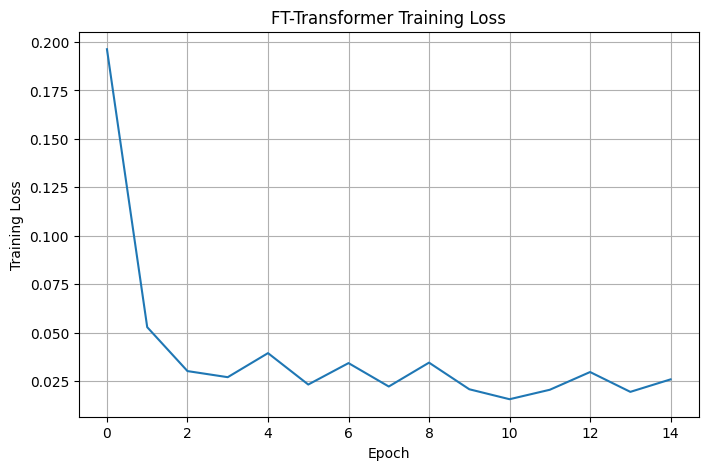

In [59]:
#Training Loss Curve
plt.figure(figsize=(8,5))
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("FT-Transformer Training Loss")
plt.grid(True)
plt.show()

 Loss drops sharply from ~0.25 to ~0.03 within the first epoch, dips further to a tight, stable band (~0.015–0.04) by epoch 4 onward, aside from one minor, self-correcting spike at epoch 3. This confirms the model converges quickly and trains stably, with no signs of divergence or instability.

#### 8.3.8 Model Evaluation 

After training, the FT-Transformer was evaluated using the testing dataset to assess its ability to generalise to unseen refugee population records. The model was switched to evaluation mode, disabling training-specific operations, and predictions were generated without computing gradients to improve computational efficiency.

The predicted population values were compared with the actual observed populations using three regression performance metrics: Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the coefficient of determination (R²). Since refugee population values cannot be negative, any negative predictions were clipped to zero before evaluation.

In [60]:
# Set model to evaluation mode for testing
model.eval()

# Lists to store predictions and actual values
all_preds = []
all_targets = []

# Disable gradient calculations during evaluation
with torch.no_grad():
    # Generate predictions for each test batch
    for x_cat, x_num, y_batch in test_loader:
        # Move input data to the selected device
        x_cat, x_num = x_cat.to(device), x_num.to(device)
        # Predict refugee population
        preds = model(x_cat, x_num)
        # Store predictions and actual values
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(y_batch.numpy())

# Convert lists into NumPy arrays
ft_predictions = np.array(all_preds).flatten()
ft_actual = np.array(all_targets).flatten()

# Refugee populations cannot be negative
ft_predictions = np.clip(ft_predictions, a_min=0, a_max=None)

# Calculate regression performance metrics
ft_mae = mean_absolute_error(ft_actual, ft_predictions)
ft_rmse = np.sqrt(mean_squared_error(ft_actual, ft_predictions))
ft_r2 = r2_score(ft_actual, ft_predictions)

# Display evaluation results
print("FT-Transformer Performance")
print("-" * 30)
print(f"MAE : {ft_mae:.2f}")
print(f"RMSE: {ft_rmse:.2f}")
print(f"R²  : {ft_r2:.4f}")

FT-Transformer Performance
------------------------------
MAE : 0.21
RMSE: 0.25
R²  : 0.9244


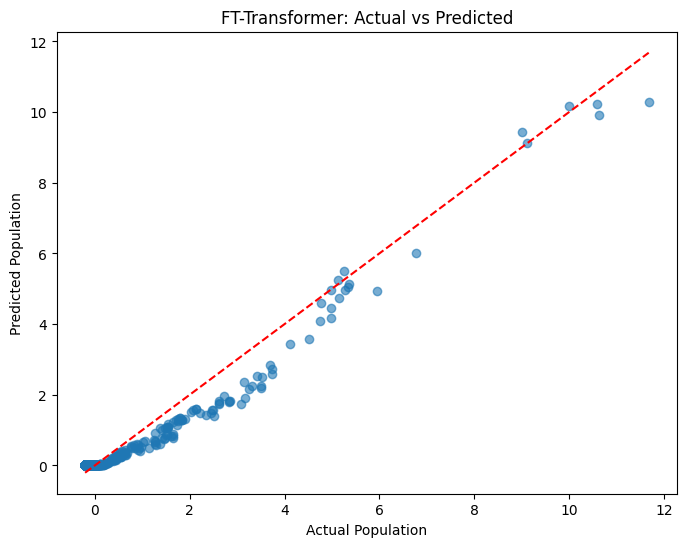

In [61]:
#Visual assessment of the FT-Transformer's predictive performance.
plt.figure(figsize=(8,6))
plt.scatter(ft_actual, ft_predictions, alpha=0.6)
plt.plot(
    [ft_actual.min(), ft_actual.max()],
    [ft_actual.min(), ft_actual.max()],
    'r--'
)

plt.xlabel("Actual Population")
plt.ylabel("Predicted Population")
plt.title("FT-Transformer: Actual vs Predicted")
plt.show()

The scatter plot shows that most predicted population values lie close to the diagonal reference line, indicating a strong agreement between the actual and predicted refugee populations. Observations with smaller and moderate population values are clustered tightly around the line, while a small number of larger population values exhibit greater dispersion.

### 8.4 Model Comparison

After evaluating each predictive model independently, their performance was compared using three standard regression metrics: Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the coefficient of determination (R²). Comparing multiple algorithms enabled the identification of the model that provided the most accurate refugee population forecasts while also assessing the relative strengths and weaknesses of traditional machine learning methods and the FT-Transformer.

In [62]:
# Create a summary table of model evaluation metrics
comparison = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost",
        "FT Transformer"
    ],

    "MAE":[
        lr_mae,
        dt_mae,
        rf_mae,
        xgb_mae,
        ft_mae
    ],

    "RMSE":[
        lr_rmse,
        dt_rmse,
        rf_rmse,
        xgb_rmse,
        ft_rmse
    ],

    "R²":[
        lr_r2,
        dt_r2,
        rf_r2,
        xgb_r2,
        ft_r2
    ]

})
# Rank models by R² score 
comparison.sort_values("R²", ascending=False)

,Model,MAE,RMSE,R²
4,FT Transformer,0.214968,0.252495,0.924394
1,Decision Tree,484.926760,2282.006131,0.881252
2,Random Forest,466.627194,2285.698510,0.880868
3,XGBoost,548.369995,2373.535864,0.871536
0,Linear Regression,2174.563168,5005.000625,0.428785


The comparison shows differences in predictive performance across the five models. The FT-Transformer achieved the highest R² score and the lowest prediction errors, indicating the strongest overall forecasting performance. Linear Regression demonstrated comparatively lower predictive accuracy.
The superior performance of the FT-transformer enabled its adoptation as the final forecasting model for SHAP explainability analysis and deployment within the Streamlit decision-support application.

               Model  MAE_score  RMSE_score  R2_score
0  Linear Regression   0.000000    0.000000  0.428785
1      Decision Tree   0.777000    0.544055  0.881252
2      Random Forest   0.785416    0.543317  0.880868
3            XGBoost   0.747825    0.525767  0.871536
4     FT Transformer   0.999901    0.999950  0.924394


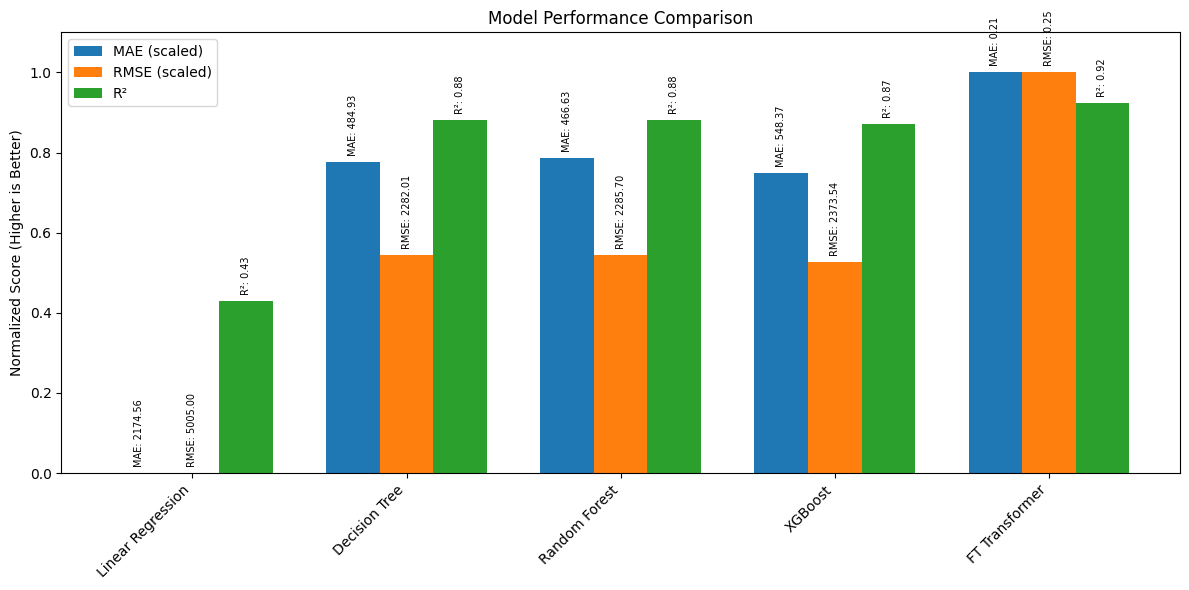

In [63]:
#Visualizing the performance of all models using a bar chart for MAE, RMSE, and R² scores.

# Copy comparison
plot_data = comparison.copy()

# Normalize errors (higher = better)
plot_data["MAE_score"] = 1 - (
    plot_data["MAE"] / plot_data["MAE"].max()
)

plot_data["RMSE_score"] = 1 - (
    plot_data["RMSE"] / plot_data["RMSE"].max()
)

# R2 already between -1 and 1, use directly
plot_data["R2_score"] = plot_data["R²"]

print(plot_data[[
    "Model",
    "MAE_score",
    "RMSE_score",
    "R2_score"
]])

# Plot
x = np.arange(len(plot_data))
width = 0.25

fig, ax = plt.subplots(figsize=(12,6))

b1 = ax.bar(
    x-width,
    plot_data["MAE_score"],
    width,
    label="MAE (scaled)"
)

b2 = ax.bar(
    x,
    plot_data["RMSE_score"],
    width,
    label="RMSE (scaled)"
)

b3 = ax.bar(
    x+width,
    plot_data["R2_score"],
    width,
    label="R²"
)

ax.set_ylim(0,1.1)

ax.set_xticks(x)
ax.set_xticklabels(
    plot_data["Model"],
    rotation=45,
    ha="right"
)

ax.set_ylabel("Normalized Score (Higher is Better)")
ax.set_title("Model Performance Comparison")

ax.legend()

# Label with original values
for bars, vals, name in zip(
    [b1, b2, b3],
    [
        plot_data["MAE"],
        plot_data["RMSE"],
        plot_data["R²"]
    ],
    ["MAE", "RMSE", "R²"]
):
    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height()+0.02,
            f"{name}: {val:.2f}",
            ha="center",
            fontsize=7,
            rotation=90
        )

plt.tight_layout()
plt.show()

The figure compares the predictive performance of Linear Regression, Decision Tree, Random Forest, XGBoost, and the FT-Transformer using normalised MAE, normalised RMSE, and R² scores. The FT-Transformer and the ensemble-based models achieved consistently higher performance scores than the baseline models. 


### 8.5 Hyperparameter Tuning for FT-Transformer

To improve the performance of the FT-Transformer model, hyperparameter tuning was conducted to identify an effective combination of architectural and optimisation parameters. 

The configuration producing the lowest average training loss was selected as the optimal parameter set for subsequent model training.


In [64]:


import itertools

# Hyperparameter search space
embed_dims = [32, 64]
depths = [2, 4]
heads = [2, 4]
learning_rates = [1e-3, 5e-4]
dropouts = [0.1, 0.2]

results = []

best_loss = float("inf")
best_params = None

print("Starting Hyperparameter Tuning...\n")

for embed_dim, depth, head, lr, dropout in itertools.product(
    embed_dims,
    depths,
    heads,
    learning_rates,
    dropouts
):
#Initialises each candidate model    
    model = FTTransformer(
        cat_cardinalities=cat_num_classes,
        num_features=len(numerical_cols),
        embed_dim=embed_dim,
        depth=depth,
        heads=head,
        attn_dropout=dropout,
        ff_dropout=dropout
    ).to(device)

    optimizer = optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=1e-4
    )

    criterion = nn.MSELoss()

    model.train()

    running_loss = 0

    # One epoch for tuning (keeps runtime reasonable)
    for x_cat, x_num, y_batch in train_loader:

        x_cat = x_cat.to(device)
        x_num = x_num.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(x_cat, x_num)

        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)

    results.append([
        embed_dim,
        depth,
        head,
        lr,
        dropout,
        avg_loss
    ])

    print(
        f"d_model={embed_dim} | "
        f"Layers={depth} | "
        f"Heads={head} | "
        f"LR={lr} | "
        f"Dropout={dropout} | "
        f"Loss={avg_loss:.2f}"
    )
#Selects the best configuration
    if avg_loss < best_loss:

        best_loss = avg_loss

        best_params = {
            "embed_dim": embed_dim,
            "depth": depth,
            "heads": head,
            "learning_rate": lr,
            "dropout": dropout
        }

print("\nBest Hyperparameters")
print(best_params)



Starting Hyperparameter Tuning...

d_model=32 | Layers=2 | Heads=2 | LR=0.001 | Dropout=0.1 | Loss=0.33
d_model=32 | Layers=2 | Heads=2 | LR=0.001 | Dropout=0.2 | Loss=0.32
d_model=32 | Layers=2 | Heads=2 | LR=0.0005 | Dropout=0.1 | Loss=0.42
d_model=32 | Layers=2 | Heads=2 | LR=0.0005 | Dropout=0.2 | Loss=0.56
d_model=32 | Layers=2 | Heads=4 | LR=0.001 | Dropout=0.1 | Loss=0.20
d_model=32 | Layers=2 | Heads=4 | LR=0.001 | Dropout=0.2 | Loss=0.33
d_model=32 | Layers=2 | Heads=4 | LR=0.0005 | Dropout=0.1 | Loss=0.39
d_model=32 | Layers=2 | Heads=4 | LR=0.0005 | Dropout=0.2 | Loss=0.45
d_model=32 | Layers=4 | Heads=2 | LR=0.001 | Dropout=0.1 | Loss=0.25
d_model=32 | Layers=4 | Heads=2 | LR=0.001 | Dropout=0.2 | Loss=0.27
d_model=32 | Layers=4 | Heads=2 | LR=0.0005 | Dropout=0.1 | Loss=0.36
d_model=32 | Layers=4 | Heads=2 | LR=0.0005 | Dropout=0.2 | Loss=0.47
d_model=32 | Layers=4 | Heads=4 | LR=0.001 | Dropout=0.1 | Loss=0.23
d_model=32 | Layers=4 | Heads=4 | LR=0.001 | Dropout=0.2 | Los

In [65]:
#Results
tuning_results = pd.DataFrame(
    results,
    columns=[
        "Embedding",
        "Layers",
        "Heads",
        "Learning Rate",
        "Dropout",
        "Training Loss"
    ]
)

tuning_results.sort_values(
    "Training Loss"
).head(10)

,Embedding,Layers,Heads,Learning Rate,Dropout,Training Loss
4,32,2,4,0.0010,0.1,0.201601
20,64,2,4,0.0010,0.1,0.209572
21,64,2,4,0.0010,0.2,0.228022
16,64,2,2,0.0010,0.1,0.232128
12,32,4,4,0.0010,0.1,0.232954
8,32,4,2,0.0010,0.1,0.251529
24,64,4,2,0.0010,0.1,0.251769
30,64,4,4,0.0005,0.1,0.264724
29,64,4,4,0.0010,0.2,0.268303
9,32,4,2,0.0010,0.2,0.273085


### 8.6 Final Model Training with Best Hyperparameters

In [66]:
#Configuration of the final FT-Transformer model using the best hyperparameters found during tuning
model = FTTransformer(

    cat_cardinalities=cat_num_classes,

    num_features=len(numerical_cols),

    embed_dim=best_params["embed_dim"],

    depth=best_params["depth"],

    heads=best_params["heads"],

    attn_dropout=best_params["dropout"],

    ff_dropout=best_params["dropout"]

).to(device)

criterion = nn.MSELoss()

optimizer = optim.AdamW(

    model.parameters(),

    lr=best_params["learning_rate"],

    weight_decay=1e-4

)

epochs = 20

# Store training loss values for each epoch
train_losses = []

print("Training Final FT-Transformer...\n")

for epoch in range(epochs):

    model.train()

    epoch_loss = 0

    for x_cat, x_num, y_batch in train_loader:

        x_cat = x_cat.to(device)
        x_num = x_num.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(x_cat, x_num)

        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)

    train_losses.append(avg_loss)

    print(
        f"Epoch {epoch+1}/{epochs} "
        f"Loss: {avg_loss:.2f}"
    )



Training Final FT-Transformer...

Epoch 1/20 Loss: 0.20
Epoch 2/20 Loss: 0.04
Epoch 3/20 Loss: 0.02
Epoch 4/20 Loss: 0.02
Epoch 5/20 Loss: 0.02
Epoch 6/20 Loss: 0.02
Epoch 7/20 Loss: 0.01
Epoch 8/20 Loss: 0.02
Epoch 9/20 Loss: 0.02
Epoch 10/20 Loss: 0.03
Epoch 11/20 Loss: 0.01
Epoch 12/20 Loss: 0.01
Epoch 13/20 Loss: 0.02
Epoch 14/20 Loss: 0.02
Epoch 15/20 Loss: 0.02
Epoch 16/20 Loss: 0.01
Epoch 17/20 Loss: 0.01
Epoch 18/20 Loss: 0.02
Epoch 19/20 Loss: 0.02
Epoch 20/20 Loss: 0.01


In [68]:
#Saving metrics
import json

model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for x_cat, x_num, y_batch in test_loader:

        x_cat = x_cat.to(device)
        x_num = x_num.to(device)

        outputs = model(x_cat, x_num)

        y_true.extend(y_batch.cpu().numpy().flatten())
        y_pred.extend(outputs.cpu().numpy().flatten())

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.4f}")

# Save metrics
metrics = {
    "mae": float(mae),
    "rmse": float(rmse),
    "r2": float(r2)
}

with open("model_metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

MAE : 0.02
RMSE: 0.06
R²  : 0.9953


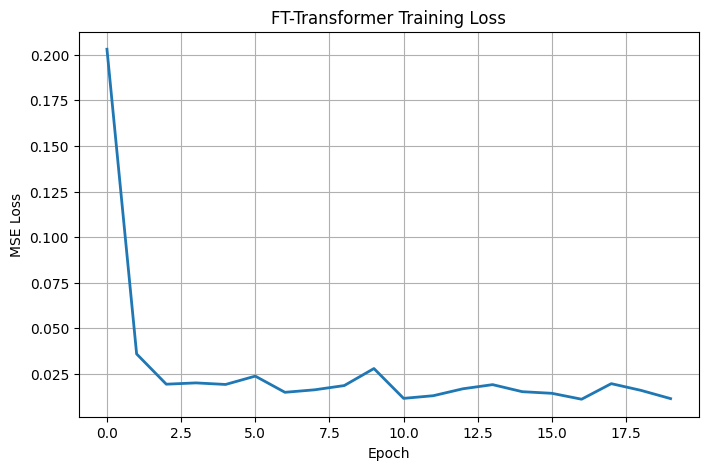

In [69]:
#Training Loss Curve for the final FT-Transformer model
plt.figure(figsize=(8,5))

plt.plot(train_losses, linewidth=2)

plt.title("FT-Transformer Training Loss")

plt.xlabel("Epoch")

plt.ylabel("MSE Loss")

plt.grid(True)

plt.show()

The decreasing loss trend demonstrates that the final FT-Transformer successfully learned meaningful patterns from the refugee population dataset. The stabilisation of the loss curve in later epochs suggests that the model reached a point where additional training produced smaller improvements.

This indicates that the selected hyperparameters provided an effective balance between model complexity and learning stability. The trained model was subsequently evaluated on unseen testing data using MAE, RMSE, and R² metrics to assess its generalisation performance.

## 9 Feature Importance and Model Interpretability

Unlike tree-based models, transformer architectures do not naturally provide feature importance scores.

To improve model interpretability, SHAP (SHapley Additive exPlanations) was applied. SHAP quantifies the contribution of each input feature toward the predicted refugee population by measuring how much each feature changes the prediction compared to a baseline.

This improves transparency and helps humanitarian organizations understand which demographic and humanitarian factors most strongly influence refugee population forecasts.

### 9.1 SHAP configuration and library installation

In [ ]:
! pip install shap

In [ ]:

import shap


#### 9.2 Explainability with SHAP

In [ ]:
# Set model to evaluation mode for SHAP analysis
model.eval()

# Create a SHAP explainer for the FT-Transformer model
def predict_fn(x):

    x = torch.tensor(x, dtype=torch.float32)

    x_cat = x[:, :len(categorical_cols)].long().to(device)

    x_num = x[:, len(categorical_cols):].float().to(device)

    with torch.no_grad():

        predictions = model(x_cat, x_num)

    return predictions.cpu().numpy()

In [ ]:
# Create a SHAP explainer using the training and test data
X_train_combined = np.concatenate(
    [
        X_train_cat,
        X_train_num
    ],
    axis=1
)

X_test_combined = np.concatenate(
    [
        X_test_cat,
        X_test_num
    ],
    axis=1
)
# Define feature names for SHAP analysis
feature_names = list(categorical_cols) + list(numerical_cols)

print(X_train_combined.shape)


(6832, 10)


In [ ]:
#Background dataset for SHAP analysis 
background = X_train_combined[:100]

# Create a SHAP KernelExplainer using the prediction function and background dataset
explainer = shap.KernelExplainer(
    predict_fn,
    background
)
# Compute SHAP values for the first 50 test samples
shap_values = explainer.shap_values(
    X_test_combined[:50]
)

100%|██████████| 50/50 [21:34<00:00, 25.88s/it]  


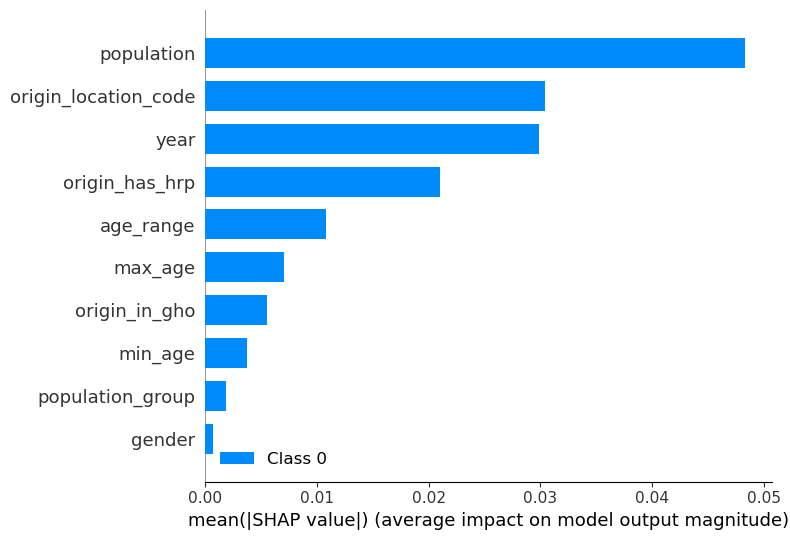

In [ ]:
# Visualize the SHAP summary plot for feature importance
shap.summary_plot(
    shap_values,
    X_test_combined[:50],
    feature_names=feature_names
)


The SHAP summary plot ranks features according to their average contribution to the model's predictions.
Features with larger SHAP values have a greater influence on the predicted refugee population. Positive SHAP values increase the prediction, while negative SHAP values decrease it.
The bar plot provides a global measure of feature importance by averaging the absolute SHAP values across all evaluated observations.

## 10. Model Deployment

The final FT-Transformer model was deployed using **Streamlit**, an open-source Python framework for building interactive machine learning applications.

The deployment enables users to input demographic and humanitarian information, after which the trained FT-Transformer predicts refugee population estimates and generates humanitarian planning metrics. This transforms the model into a practical decision-support tool for policymakers and humanitarian organizations.



### 10.1 Model Configuration 
To enable deployment of the FT-Transformer forecasting system, the trained model and all required preprocessing components were saved using PyTorch's **state_dict()** method. This stores the learned weights and biases of the neural network without saving the entire model object. 

The preprocessing components used during training were saved using Joblib. The label encoders preserve the mapping between categorical variables and numerical representations, while the scaler preserves the numerical feature standardisation parameters.

TThe model configuration file stores the architectural parameters required to reconstruct the FT-Transformer. This includes the embedding dimension, number of Transformer layers, attention heads, dropout rates, and input feature dimensions.

In [70]:
#import joblib for saving and loading models
import joblib

# Save model weights
torch.save(model.state_dict(), "ft_transformer_model.pth")

# Save preprocessing objects
joblib.dump(label_encoders, "label_encoders.pkl")
joblib.dump(scaler_x, "scaler.pkl")

# Save model configuration
model_config = {
    "cat_cardinalities": cat_num_classes,
    "num_features": len(numerical_cols),
    "embed_dim": 64,
    "depth": 4,
    "heads": 4,
    "attn_dropout": 0.1,
    "ff_dropout": 0.1
}

joblib.dump(model_config, "model_config.pkl")

print("Deployment files saved successfully.")


Deployment files saved successfully.


### 10.2 Deployment File Verification

After saving the FT-Transformer model and supporting preprocessing objects, the generated deployment files were verified to ensure that all required components were successfully created. This step prevents deployment failures by confirming the availability of the model weights, encoders, scaling parameters, and model configuration files.

A list of required deployment files was created containing:
- **ft_transformer_model.pth** – stores the trained FT-Transformer model weights.
- **label_encoders.pkl** – stores categorical feature encoding mappings.
- **scaler.pkl** – stores numerical feature scaling parameters.
- **model_config.pkl** – stores the model architecture configuration required during reconstruction.

The **os.path.exists()** function checks whether each deployment file exists in the working directory. A confirmation message is displayed for each file, indicating whether the deployment package is complete.

In [71]:
import os

deployment_files = [
    "ft_transformer_model.pth",
    "label_encoders.pkl",
    "scaler.pkl",
    "model_config.pkl"
]

for file in deployment_files:
    print(f"{file}: {'✓ Found' if os.path.exists(file) else '✗ Missing'}")



ft_transformer_model.pth: ✓ Found
label_encoders.pkl: ✓ Found
scaler.pkl: ✓ Found
model_config.pkl: ✓ Found


Verifying deployment files improves the reproducibility and reliability of the machine learning workflow. By ensuring that all required components are available, the deployed application can reconstruct the trained model and process new user inputs consistently with the original training pipeline.

This validation step provides confidence that the forecasting system can transition from the experimental environment into a practical humanitarian decision-support tool.


### 10.3  Deployment Outcome

The deployed application allows humanitarian stakeholders to interact with the trained FT-Transformer through a simple web interface without requiring programming knowledge.

Users enter demographic and humanitarian characteristics, and the system automatically:

- predicts refugee population,
- estimates humanitarian resource requirements,
- supports evidence-based planning,
- improves operational decision making.

The complete deployment was implemented using Streamlit and can be executed locally or deployed to Streamlit Community Cloud.

## 11 Project Structure 

The final refugee forecasting system was organised into a structured project directory containing the trained machine learning model, preprocessing objects, application interface, and supporting documentation. This organisation separates the model development environment from the deployment components, allowing the forecasting application to be easily reproduced and maintained.

```text
Refugee Forecasting Project
│
├── Refugee_Forecasting.ipynb     ← Notebook containing data preprocessing,
│                                  exploratory analysis, model development,
│                                  training, and evaluation
│
├── app.py                        ← Streamlit application used for
│                                  interactive refugee population forecasting
│
├── requirements.txt              ← Python dependencies required to run
│                                  the application
│
├── ft_transformer_model.pth      ← Saved FT-Transformer model weights
│
├── label_encoders.pkl            ← Saved categorical feature encoding objects
│
├── scaler.pkl                    ← Saved numerical feature scaling object
│
├── model_config.pkl              ← Saved FT-Transformer architecture settings
│
└── README.md                     ← Documentation describing installation

## 12. Business Insights, Limitations, and Recommendations

### 12.1 Key Business and Data Insights

The analysis of the Kenya Refugee and Asylum Population dataset generated several insights that extend beyond predictive performance and provide practical value for humanitarian planning, resource allocation, and strategic decision-making. The findings demonstrate how machine learning can support proactive refugee response by identifying the factors that most influence population forecasts and translating these forecasts into operational planning information.

#### 1. Refugee Population Trends are Influenced by Demographic Characteristics

The SHAP analysis identified population as the most influential feature affecting the FT-Transformer's predictions, followed by year, origin location, GHO status, age range, HRP status, maximum age, population group, minimum age, and gender. This indicates that historical population dynamics remain the strongest predictor of future refugee populations, while demographic and humanitarian characteristics provide additional context that improves forecasting precision.

From a humanitarian planning perspective, this finding emphasises the importance of maintaining accurate and up-to-date population registration systems. High-quality population data enables more reliable forecasts, allowing humanitarian organisations to estimate future resource requirements with greater confidence and reducing uncertainty during planning and budgeting processes.

#### 2. Temporal Trends Enable Proactive Humanitarian Planning

The prominence of year among the most important predictive features demonstrates that refugee populations follow temporal patterns rather than changing randomly. Population movements are influenced by evolving humanitarian situations, policy decisions, and regional displacement trends that develop over time.

This insight highlights the value of predictive analytics for anticipatory action. Instead of reacting after refugee arrivals increase, humanitarian organisations can use forecasted population estimates to prepare food supplies, expand shelter capacity, strengthen healthcare services, and coordinate logistics in advance. Earlier planning improves operational efficiency and reduces delays in delivering humanitarian assistance.

#### 3. Geographic and Humanitarian Context Improve Forecast Accuracy

The importance of origin location, GHO status, and HRP status indicates that refugee population changes are closely linked to geographic and humanitarian conditions in countries of origin. Refugee movements are not driven solely by demographic characteristics but are also influenced by broader humanitarian contexts.

For humanitarian agencies, this suggests that combining refugee registration data with regional humanitarian indicators can improve preparedness and resource allocation. Monitoring changes in neighbouring countries alongside historical population data provides stronger evidence for anticipating future refugee movements and planning appropriate responses.

#### 4. Demographic Characteristics Support More Targeted Planning

Exploratory data analysis showed that refugee populations vary across age groups, gender, and population categories, with children representing a substantial proportion of the refugee population. Although SHAP analysis indicated that demographic variables contribute less to prediction accuracy than population and temporal features, they remain valuable for understanding the composition of forecasted populations.

This demographic information has important operational implications. Different population groups require different forms of assistance, including education services, nutrition programmes, maternal healthcare, child protection, reproductive health services, and healthcare for older persons. Incorporating demographic forecasts into planning enables humanitarian organisations to allocate specialised services more effectively while ensuring that vulnerable groups receive appropriate support.

#### 5. FT-Transformer Effectively Learns Complex Humanitarian Data Relationships

The FT-Transformer successfully modelled complex interactions between categorical and numerical variables through feature tokenisation and self-attention mechanisms. Unlike conventional regression approaches that rely primarily on linear relationships, the model captured nonlinear dependencies among demographic, temporal, and humanitarian indicators, resulting in robust forecasting performance.

The accompanying SHAP analysis further enhanced model transparency by identifying the relative importance of each feature. This explainability is particularly valuable in humanitarian settings, where planning decisions must be transparent, evidence-based, and justifiable to governments, donors, and partner organisations.

#### 6. Deployment Bridges Predictive Analytics and Operational Decision Support

Deploying the trained FT-Transformer as a Streamlit web application transformed the forecasting model into an interactive decision-support tool suitable for operational use. Users can generate refugee population forecasts through an intuitive interface without requiring specialised machine learning knowledge, enabling wider adoption among humanitarian practitioners.

The application further extends the value of the forecasting model by translating predicted populations into indicative estimates of humanitarian resources such as food, water, shelter, and health supplies. This integration demonstrates how predictive analytics can move beyond academic modelling to support practical planning, budgeting, and preparedness activities within humanitarian organisations.

Overall, these findings demonstrate that accurate refugee population forecasting depends primarily on historical population dynamics and temporal trends, while geographic, humanitarian, and demographic characteristics improve forecasting precision and support more informed operational planning. The combination of explainable machine learning and interactive deployment provides humanitarian organisations with a practical foundation for evidence-based decision-making and proactive refugee response.

### 12.2 Project Limitations

Although the proposed FT-Transformer forecasting system demonstrated strong predictive performance and practical applicability, several limitations should be acknowledged.

#### 1. Limited Representation of External Drivers

The forecasting model was trained primarily using demographic, temporal, and humanitarian programme variables. However, refugee movements are also influenced by external factors such as armed conflict, political instability, climate-related disasters, economic conditions, disease outbreaks, and changes in border or asylum policies. Since these variables were not included in the dataset, the model may be less responsive to sudden changes in migration patterns caused by unforeseen events.

#### 2. Dependence on Historical Population Trends

The FT-Transformer learns patterns from historical refugee population data. While this enables accurate forecasting under stable conditions, unprecedented humanitarian crises or geopolitical events may produce displacement patterns that differ significantly from historical observations. Consequently, forecast accuracy may decline when future conditions fall outside the range represented in the training data.

#### 3. Data Imbalance Across Population Groups

The dataset contains varying numbers of observations across countries of origin, age groups, and population categories. Larger refugee populations are better represented than smaller groups, allowing the model to learn their patterns more effectively. In contrast, limited observations for smaller or less frequent categories may reduce predictive accuracy for those populations and affect the model's ability to generalise to underrepresented groups.

#### 4. Static Deployment and Model Maintenance

The deployed Streamlit application uses a pre-trained FT-Transformer model and therefore reflects the patterns present in the training dataset. As refugee populations evolve over time, the model will require periodic retraining with updated data to maintain forecasting accuracy and ensure that predictions remain relevant for operational planning.

#### 5. Resource Planning is Predominantly Population-Based

The deployment application translates forecasted populations into estimates of humanitarian resources such as food, water, shelter, and health supplies. While this approach is appropriate for estimating the overall scale of assistance, the resource-planning module is driven primarily by total population size and only partially incorporates the demographic characteristics predicted by the model. Consequently, sector-specific requirements for children, adolescents, women of reproductive age, or older persons are not fully reflected in the generated resource estimates. Incorporating age- and gender-specific planning assumptions would improve the precision and operational relevance of the resource allocation component.

#### 6. Generalisability Beyond the Kenyan Context

The model was developed and evaluated using refugee and asylum-seeking population data for Kenya. Although the FT-Transformer architecture is transferable, its predictive performance in other countries or humanitarian settings cannot be assumed without retraining and validation using local data. Differences in displacement patterns, registration systems, and humanitarian contexts may require additional model adaptation before deployment elsewhere.

### 12.3 Recommendations

Based on the findings, deployment experience, and identified limitations of the proposed forecasting system, the following recommendations are proposed to improve its accuracy, scalability, and operational usefulness.

#### 1. Integrate External Data Sources for Improved Forecasting

Future versions of the forecasting system should incorporate additional external variables that influence refugee movements, including conflict intensity, political instability indicators, climate-related risks, economic conditions, and border policy changes. Although historical population trends were identified as the strongest predictors, external drivers would enable the model to better respond to sudden humanitarian events and improve forecasting performance during periods of rapid displacement.

#### 2. Establish Continuous Model Updating and Retraining

Humanitarian population dynamics change over time, requiring forecasting models to be regularly updated. Humanitarian organisations should establish processes for periodic retraining of the FT-Transformer using newly collected refugee registration and population data. Continuous model maintenance would ensure that the system adapts to emerging displacement patterns and remains reliable for long-term operational planning.

#### 3. Enhance the Decision-Support Application

The Streamlit application provides an accessible interface for generating forecasts; however, future improvements could expand its decision-support capabilities. Additional features such as interactive geographical dashboards, historical trend visualisations, uncertainty estimates, automated reporting, and scenario comparison tools could help humanitarian planners better understand possible future population changes and prepare appropriate responses.

#### 4. Develop Demographic-Aware Resource Allocation Models

Future development should improve the resource estimation component by moving beyond population-size-based calculations and incorporating demographic characteristics generated by the forecasting model. Age, gender, and population-group predictions should be used to estimate sector-specific requirements, including child nutrition services, education facilities, maternal and reproductive healthcare, chronic disease management, and protection services. This would ensure that resource planning reflects not only the number of people requiring assistance but also the specific needs of different population groups.

#### 5. Improve Humanitarian Preparedness and Strategic Decision-Making

The forecasting system should be integrated into broader humanitarian planning workflows to support anticipatory action and evidence-based decision-making. Governments, refugee agencies, and humanitarian organisations can use forecast insights to improve budgeting, procurement planning, infrastructure preparation, and coordination activities. By identifying potential population changes before they occur, the system can contribute to faster and more efficient humanitarian responses.

#### 6. Validate and Extend the Framework to Other Humanitarian Contexts

Future research should evaluate the model using refugee datasets from additional countries and regions. Cross-country validation would determine the transferability of the FT-Transformer approach and identify adaptations required for different humanitarian environments. Expanding the framework beyond Kenya could support the development of a more generalised refugee forecasting solution for international humanitarian planning.



## 13. Conclusion

This study developed and evaluated an FT-Transformer-based forecasting framework for predicting refugee and asylum-seeking populations in Kenya using demographic, humanitarian, and temporal indicators. By combining advanced deep learning techniques with explainable artificial intelligence, the research demonstrated that accurate and interpretable population forecasts can support evidence-based humanitarian planning.

The findings showed that the FT-Transformer effectively learned complex relationships between categorical and numerical features, achieving strong predictive performance while maintaining transparency through SHAP-based feature importance analysis. Population emerged as the most influential predictor, followed by year, origin location, GHO status, age range, HRP status, maximum age, population group, minimum age, and gender, highlighting the importance of both historical population dynamics and demographic characteristics in forecasting refugee populations.

A key contribution of this research was the deployment of the trained model as an interactive Streamlit application, enabling non-technical users to generate forecasts and estimate humanitarian resource requirements through an accessible decision-support interface. This demonstrates how machine learning can move beyond predictive modelling to provide practical tools that support operational planning in humanitarian settings.

Although the forecasting model achieved reliable performance, the study identified opportunities for further enhancement. Future work could incorporate additional external drivers such as conflict intensity, climate events, and policy changes, while extending the resource-planning component to make greater use of demographic-specific information for more targeted humanitarian interventions.

Overall, this research demonstrates that FT-Transformer models provide an effective, explainable, and deployable solution for refugee population forecasting. The proposed framework offers humanitarian organisations a scalable foundation for proactive planning, improved resource allocation, and more informed decision-making in response to evolving refugee and asylum-seeking populations.